# **1. DESCOMPOSICION DE UNA SERIE DE TIEMPO**
*Colab, API, etc*

In [1]:
import pandas as pd
import numpy as np
from random import gauss
from pandas.plotting import autocorrelation_plot
import warnings
import itertools
from random import random




import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
from string import ascii_letters
import seaborn as sns


# general settings
class CFG:
    data_folder = '../data/'
    img_dim1 = 25
    img_dim2 = 8
    style = 'fivethirtyeight'
    
    
# adjust the parameters for displayed figures    
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})    
plt.style.use(CFG.style) 


# FUNCION PARA API
def sdt_get(serie,**kwargs):
  '''
  kwargs: 
              - start_date/end_date
              - collapse: week / month / quarter / year
              - collapse_aggregation: min / max / avg (default) / end_of_period * sólo se puede usar para consultas individuales
              - representation_mode: value (default) / change / change_a_year_ago / change_since_beginning_of_year / percent_change / percent_change_a_year_ago / percent_change_since_beginning_of_year
  '''
  if isinstance(serie, list):
    serie_ls = serie
    serie = ','.join(serie)
  settings = serie+'&'
  for k,v in kwargs.items():
    settings = settings + f"{k}={v}"+'&'
  print(settings)
  data = f"https://apis.datos.gob.ar/series/api/series/?format=csv&last=5000&ids={settings}"
  output = pd.read_csv(data).set_index('indice_tiempo')
  output.index = pd.to_datetime(output.index)
  return output

# Descomposición

## Estimador Mensual de la Actividad Económica

In [12]:
import pandas as pd
import requests
from io import StringIO

def sdt_get(serie, **kwargs):
    settings = ','.join(serie)
    url = f"https://apis.datos.gob.ar/series/api/series/?format=csv&last=5000&ids={settings}"
    
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        data = StringIO(response.text)
        df = pd.read_csv(data).set_index('indice_tiempo')
        df.index = pd.to_datetime(df.index)
        return df
    else:
        raise Exception(f"HTTP Error: {response.status_code} - {response.reason}")

# Example call
df = sdt_get(['143.3_NO_PR_2004_A_31', '143.3_NO_PR_2004_A_28', '143.3_NO_PR_2004_A_21'])
df.head(2)


,emae_desestacionalizada,emae_tendencia_ciclo,emae_original
indice_tiempo,,,
2004-01-01,98.417813,96.048930,92.627506
2004-02-01,98.164075,96.650517,90.186179


In [18]:
df = sdt_get(['143.3_NO_PR_2004_A_31','143.3_NO_PR_2004_A_28','143.3_NO_PR_2004_A_21'])
df.head(2)

,emae_desestacionalizada,emae_tendencia_ciclo,emae_original
indice_tiempo,,,
2004-01-01,98.417813,96.048930,92.627506
2004-02-01,98.164075,96.650517,90.186179


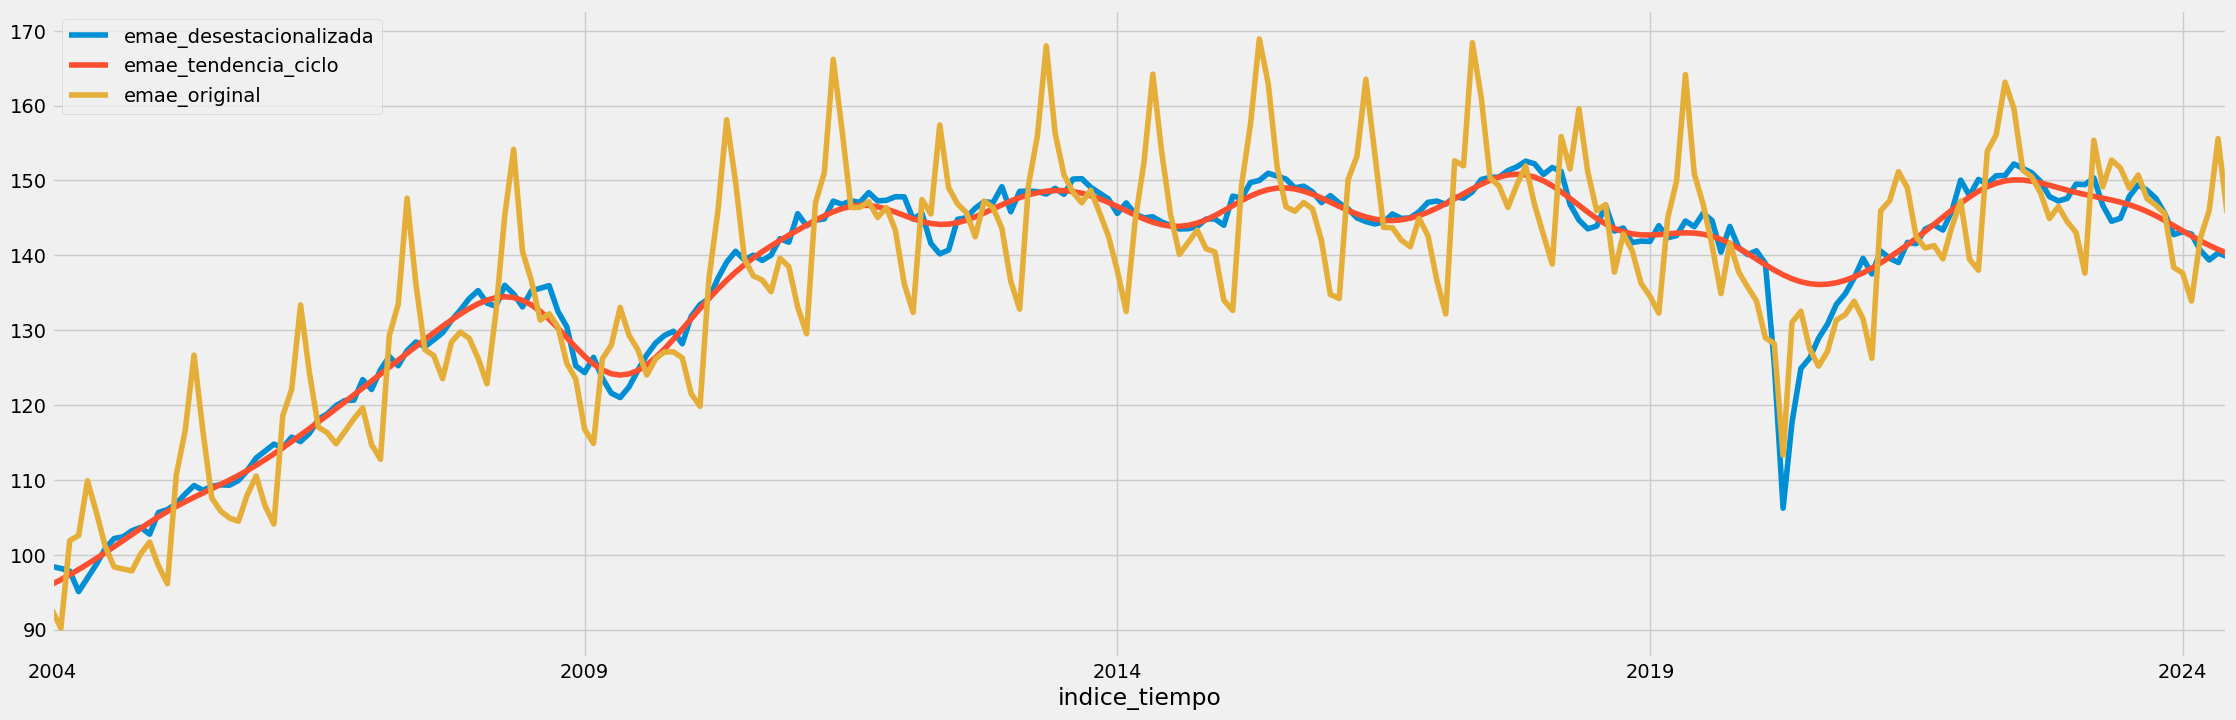

In [19]:
df.plot();

### **Aditiva**

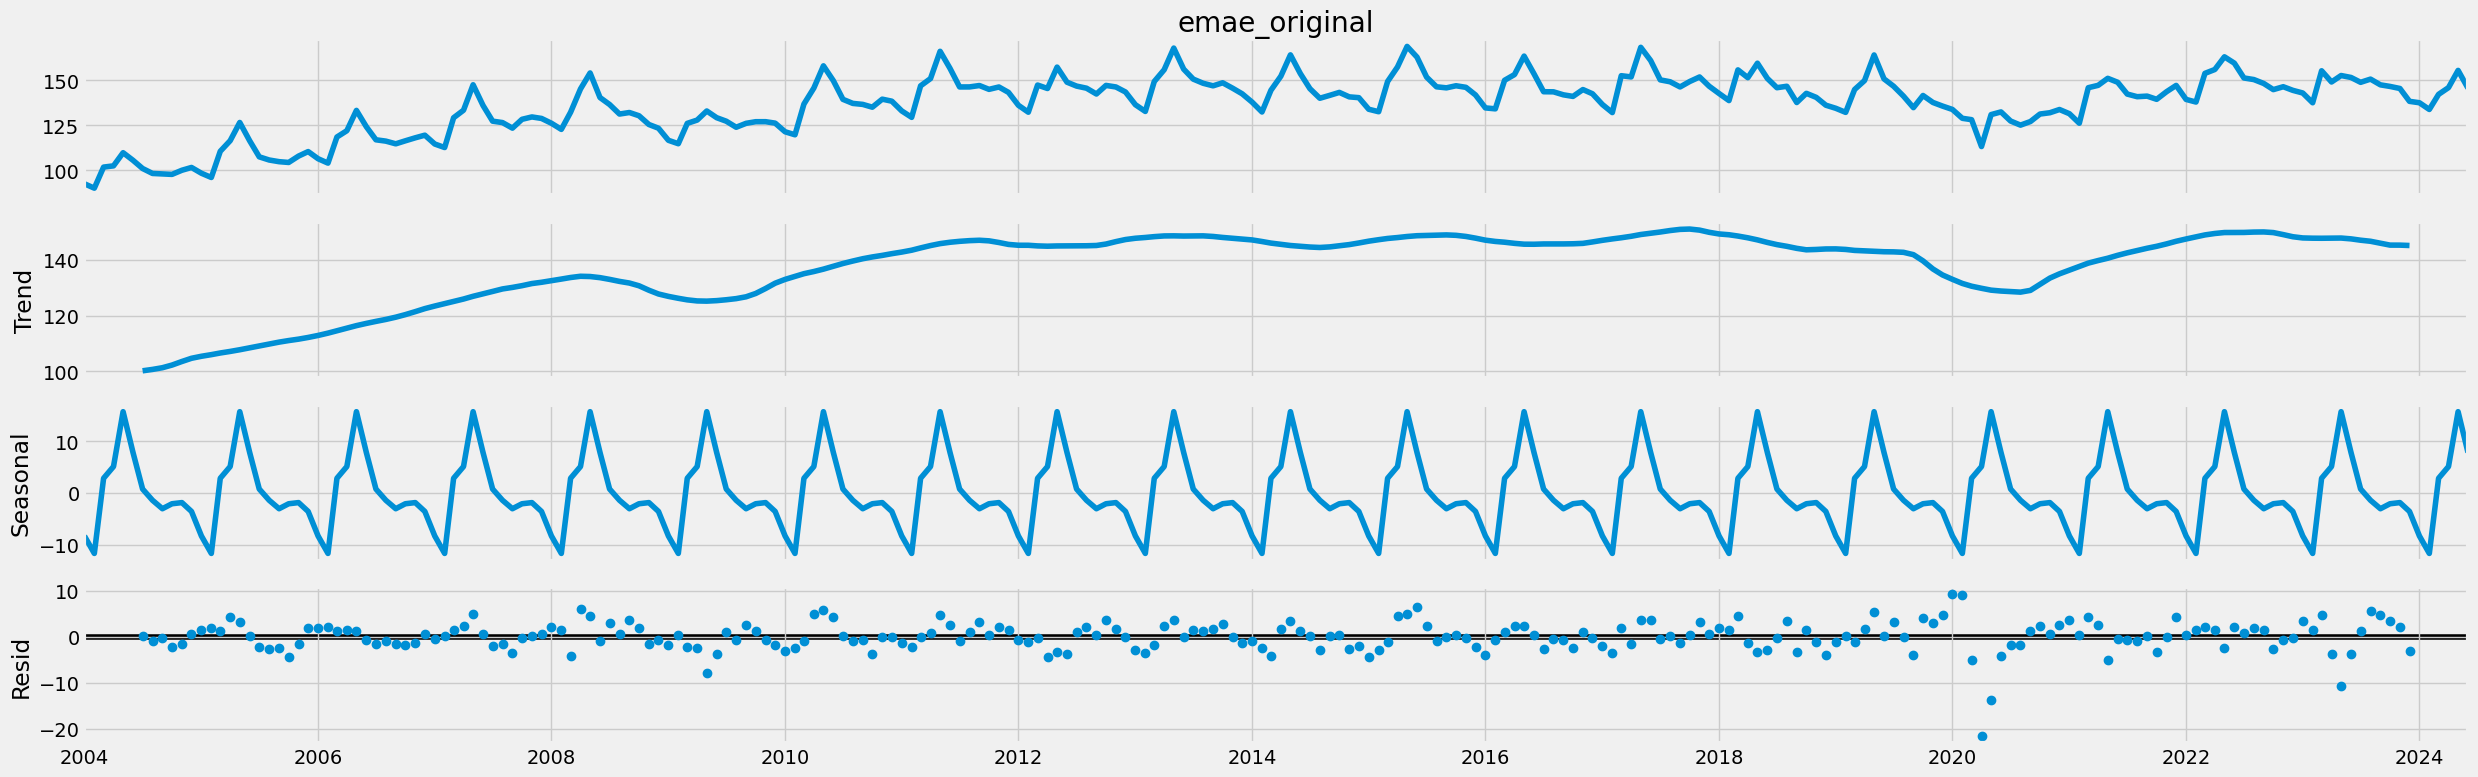

In [20]:
# decomposition
decomposition = sm.tsa.seasonal_decompose(df["emae_original"],period =12) 
figure = decomposition.plot()
plt.show()

### **Multiplicativa**

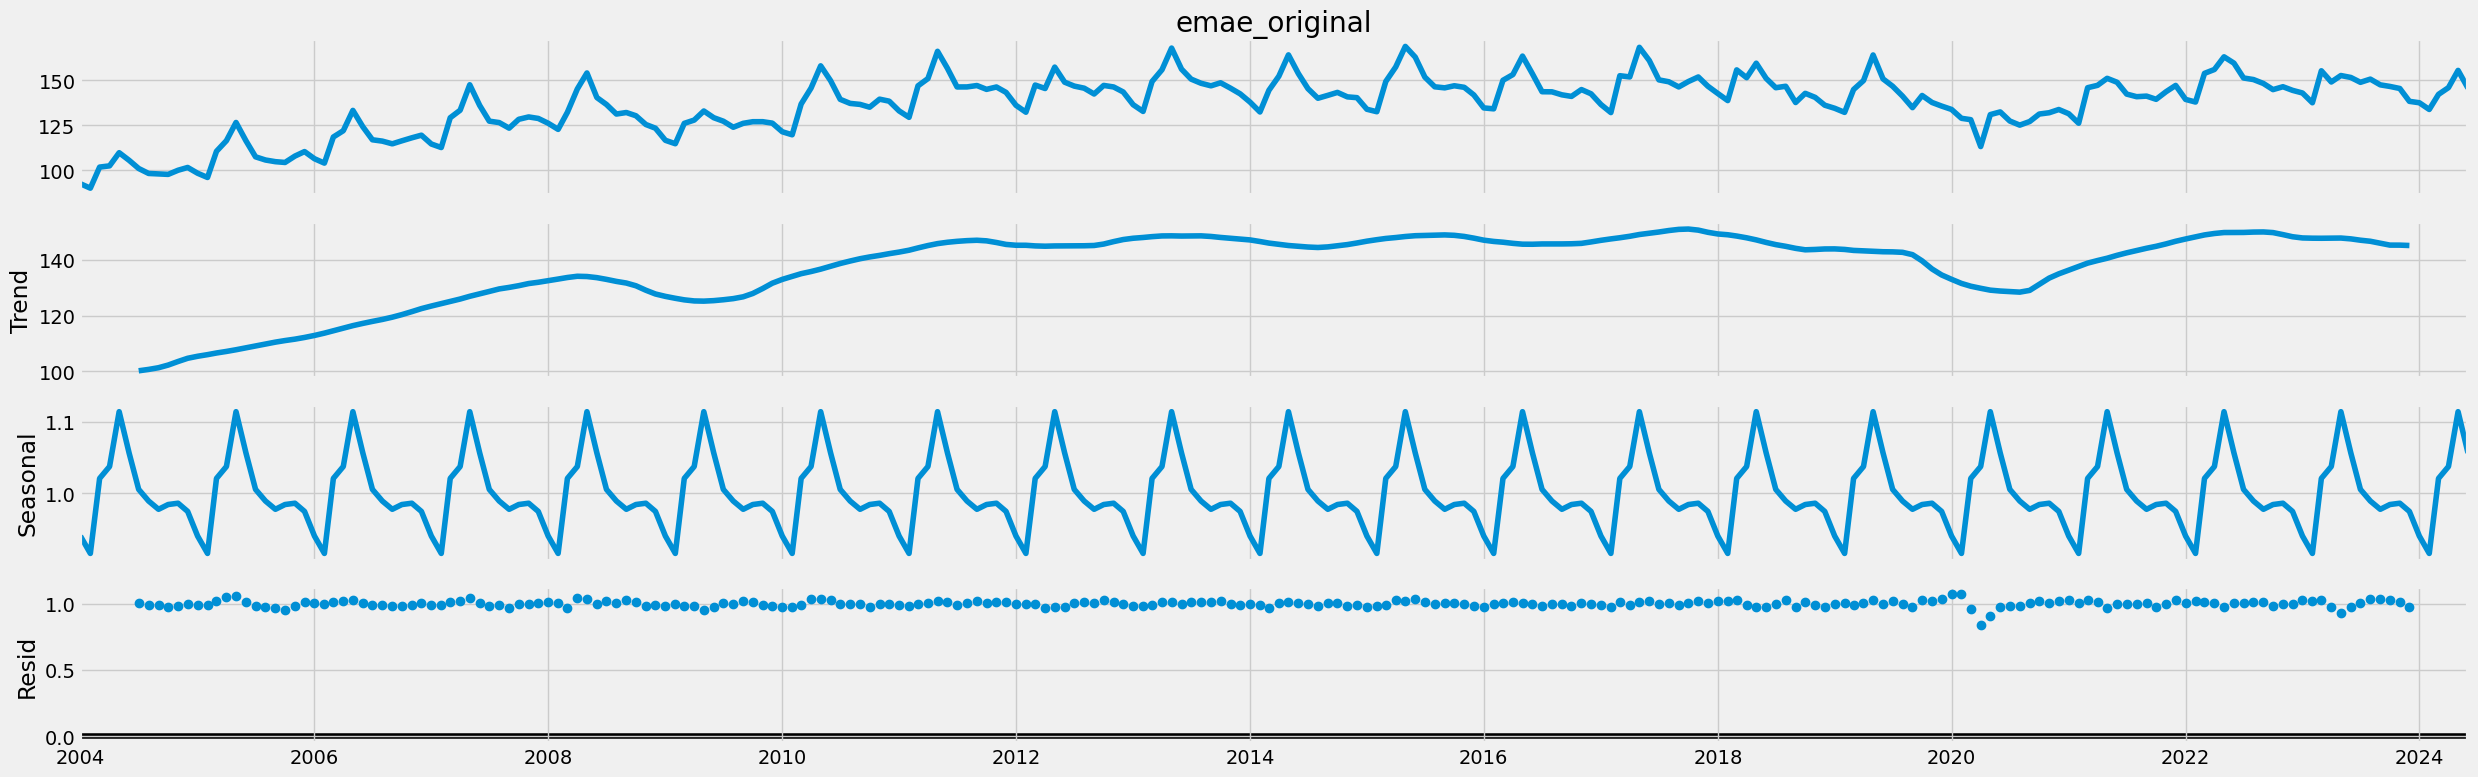

In [7]:
decomposition = sm.tsa.seasonal_decompose(df["emae_original"],period =12, model = 'multiplicative') 
figure = decomposition.plot()
plt.show()

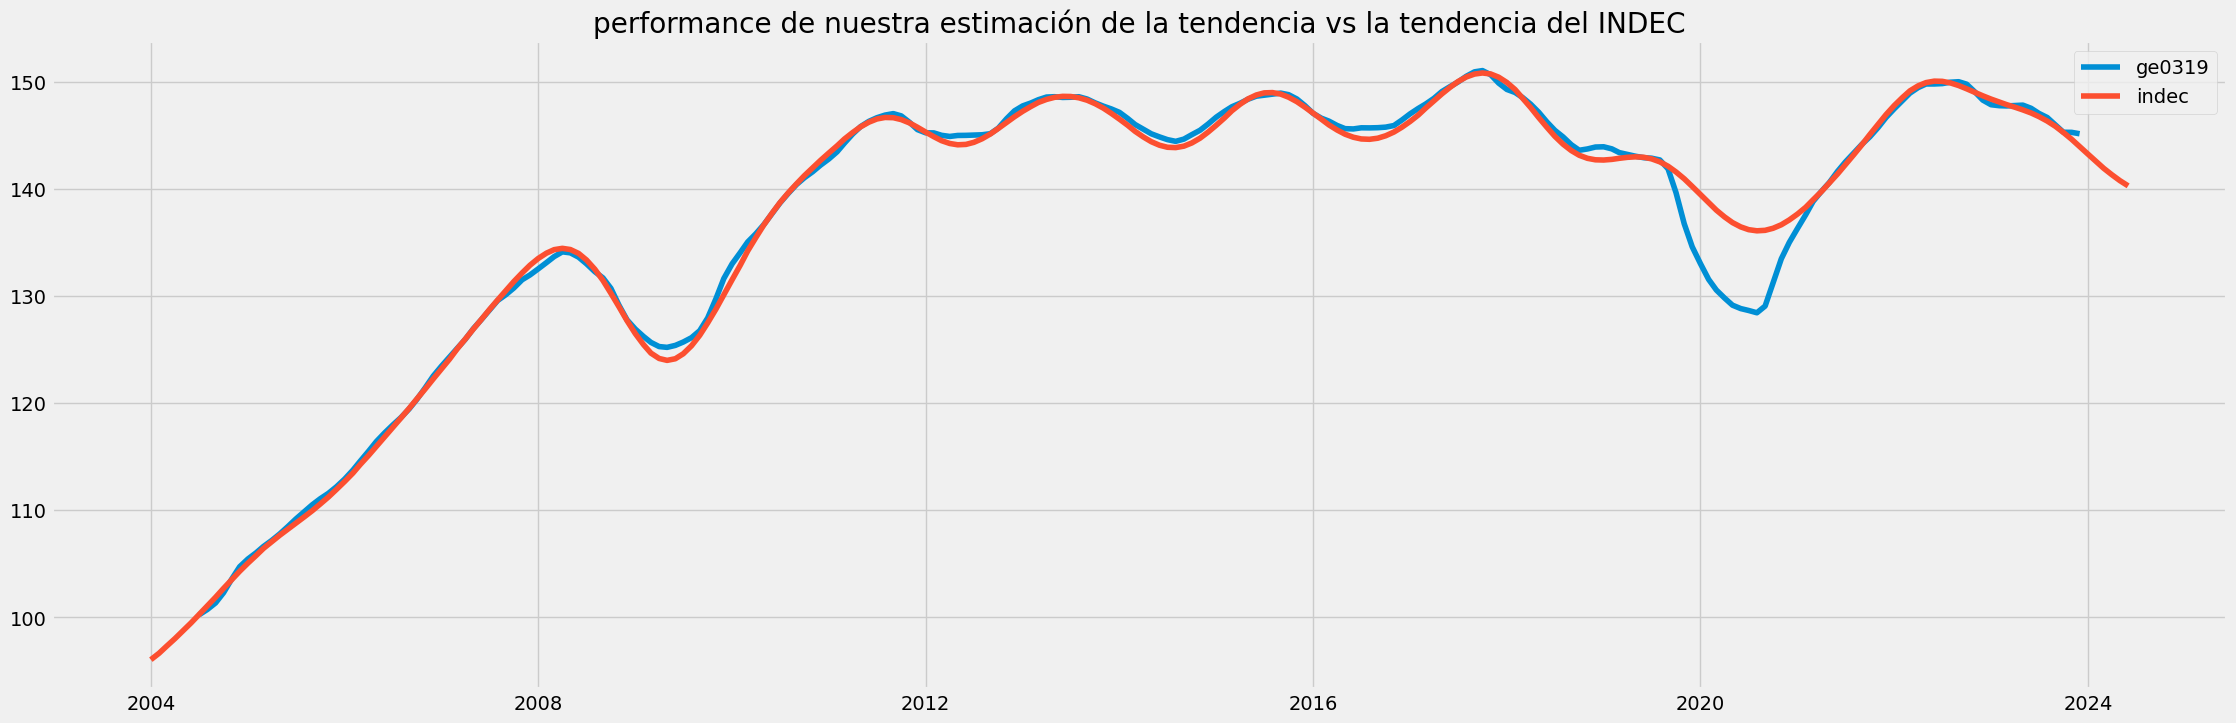

In [21]:
plt.plot(decomposition._trend,label='ge0319')
plt.plot(df.emae_tendencia_ciclo,label='indec');
plt.title('performance de nuestra estimación de la tendencia vs la tendencia del INDEC')
plt.legend()

## Estudio por Sectores


In [23]:
df = sdt_get(['143.3_NO_PR_2004_A_21',
 '11.3_VMATC_2004_M_12',
 '11.3_VMASD_2004_M_23',
 '11.3_VIPAA_2004_M_5',
 '11.3_ISOM_2004_M_39',
 '11.3_P_2004_M_20',
 '11.3_AGCS_2004_M_41']) #678arlyc

df.head(2)

,emae_original,construccion,industria_manufacturera,pesca,agricultura_ganaderia_caza_silvicultura,hoteles_restaurantes,comercio_mayorista_minorista_reparaciones
indice_tiempo,,,,,,,
2004-01-01,92.627506,95.938047,91.454610,42.547868,65.995350,108.411682,92.065338
2004-02-01,90.186179,98.853388,89.424852,62.440771,64.926598,103.448256,91.464718


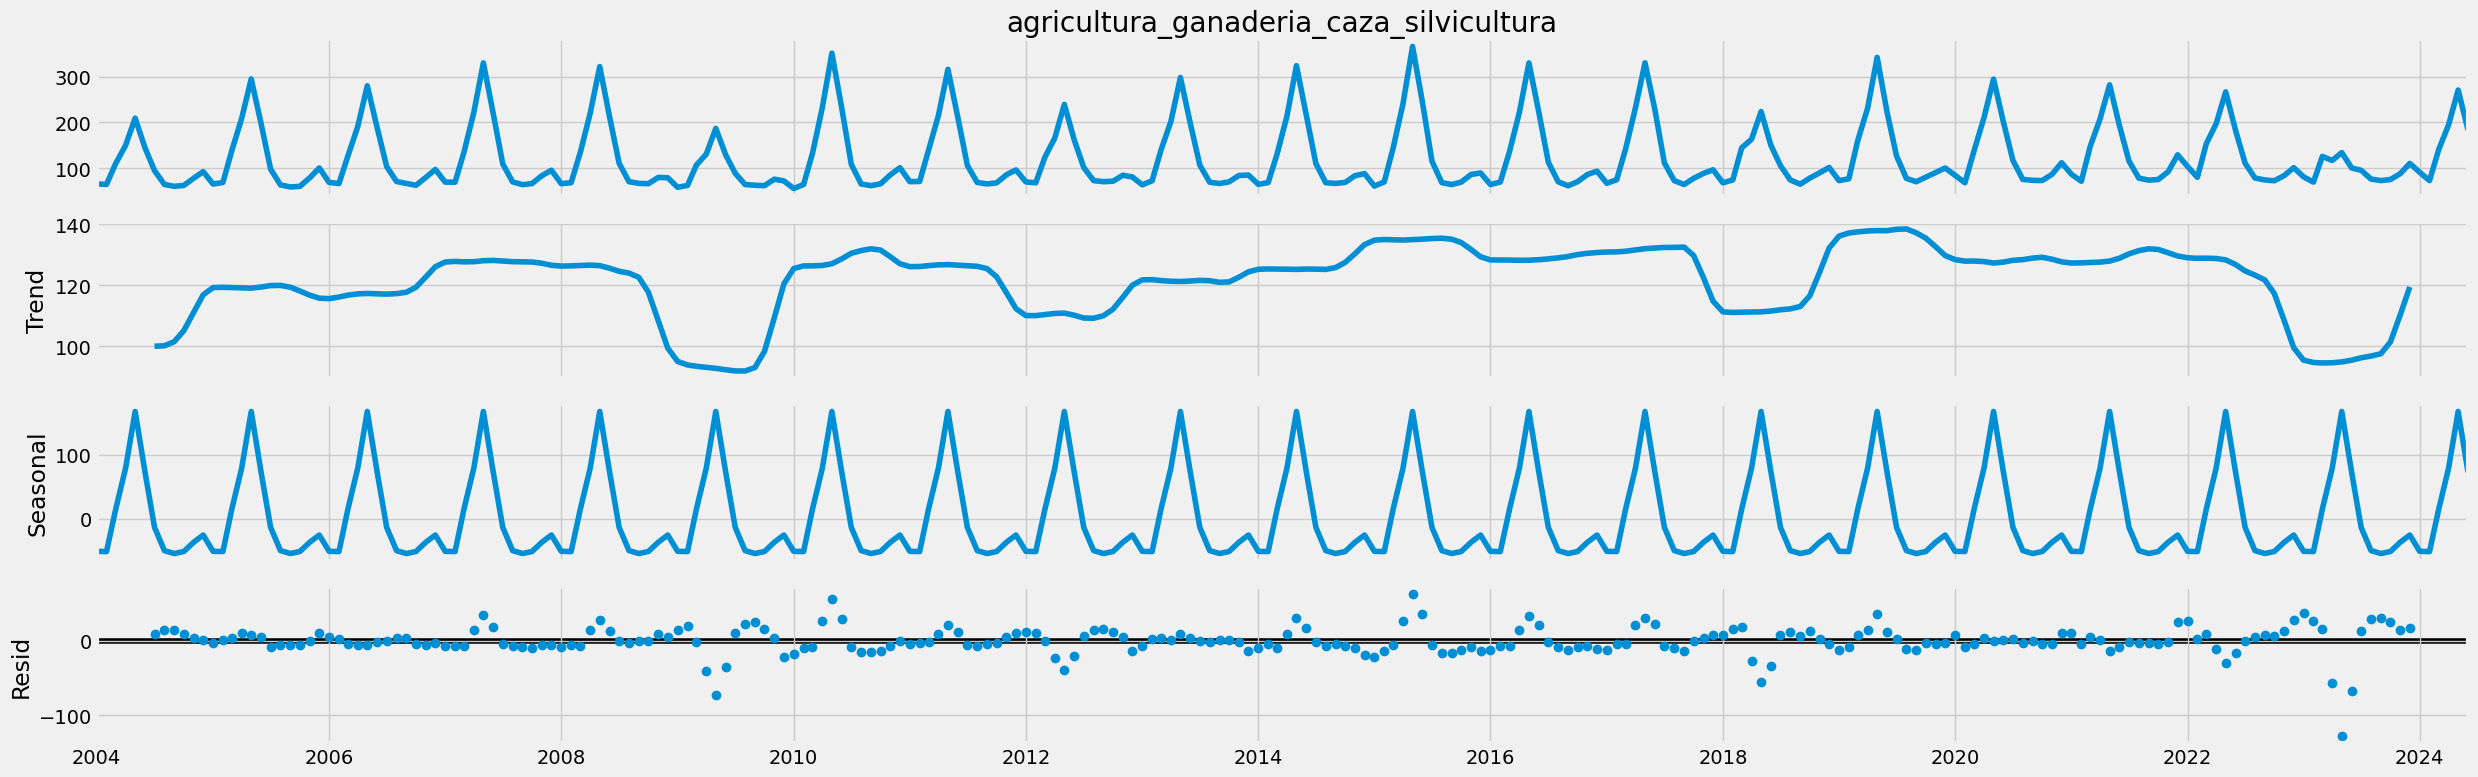

In [24]:
decomposition = sm.tsa.seasonal_decompose(df["agricultura_ganaderia_caza_silvicultura"],period =12) 
figure = decomposition.plot()
plt.show()

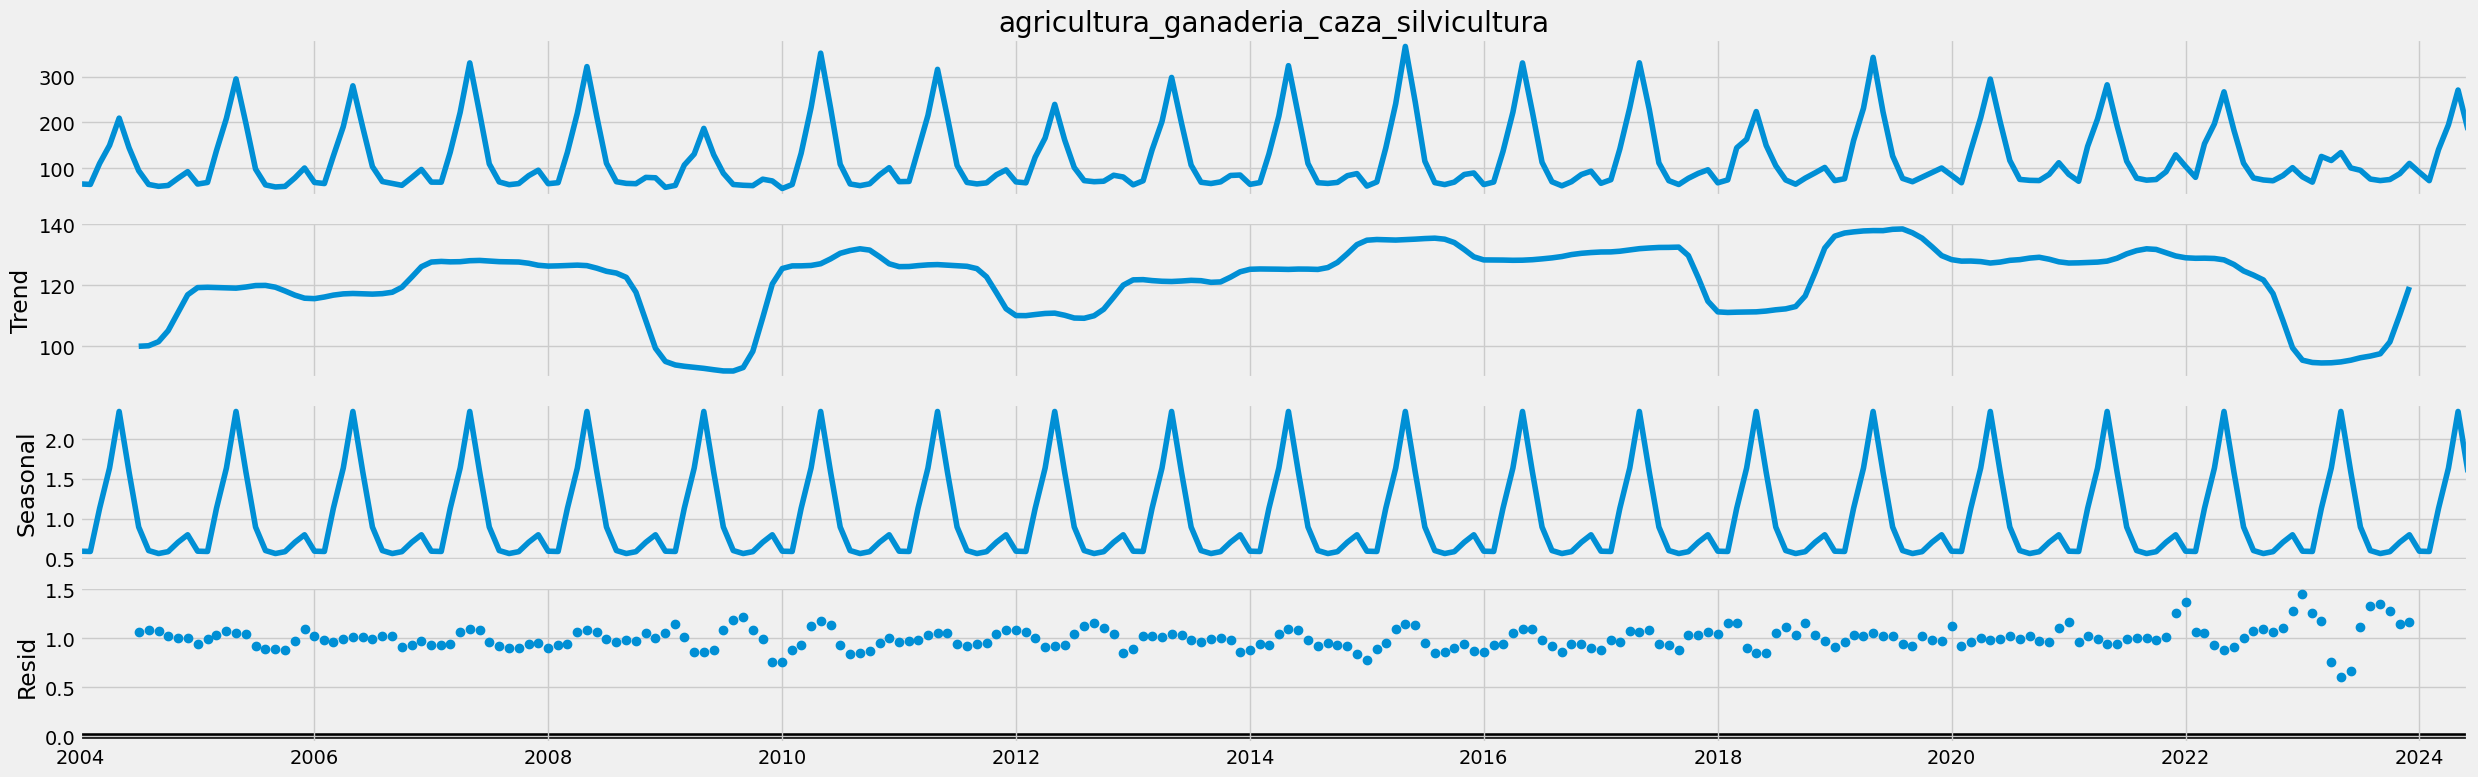

In [25]:
decomposition = sm.tsa.seasonal_decompose(df["agricultura_ganaderia_caza_silvicultura"],period =12, model = 'multiplicative') 
figure = decomposition.plot()
plt.show()

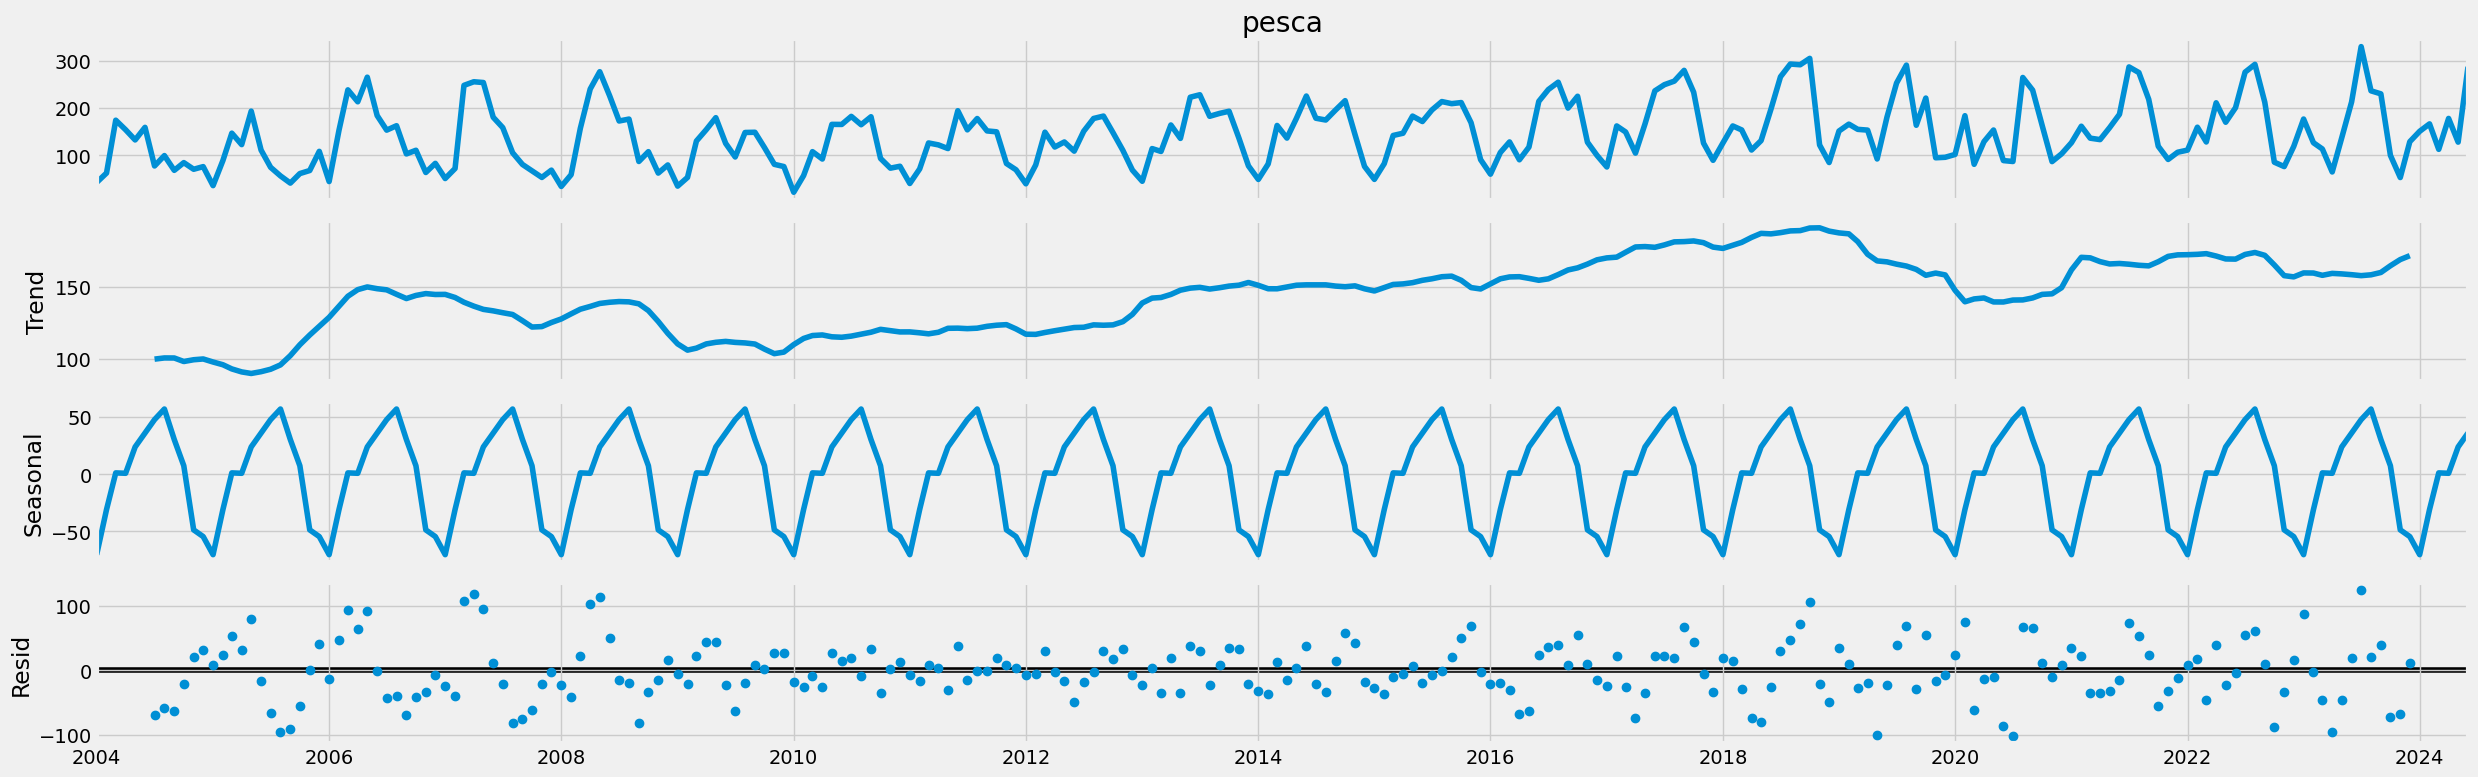

In [26]:
decomposition = sm.tsa.seasonal_decompose(df["pesca"],period =12)
figure = decomposition.plot()
plt.show()

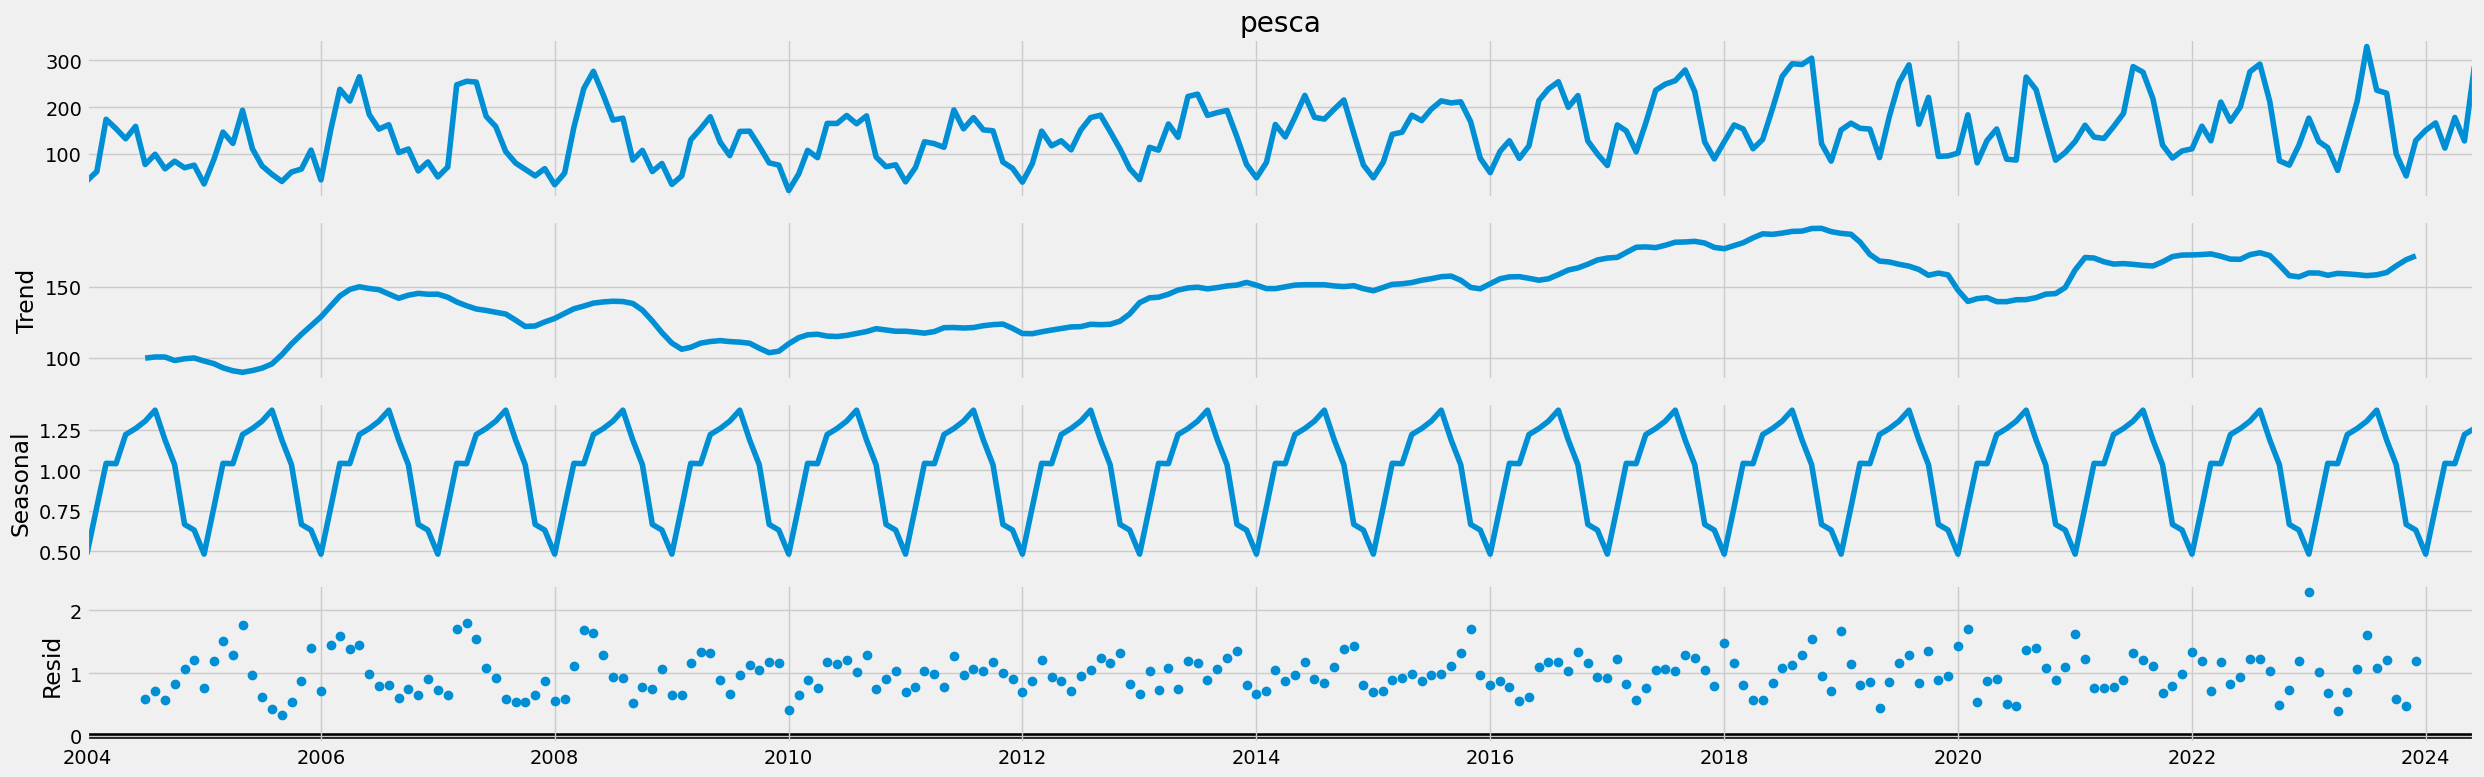

In [27]:
decomposition = sm.tsa.seasonal_decompose(df["pesca"],period =12, model = 'multiplicative')  
figure = decomposition.plot()
plt.show()

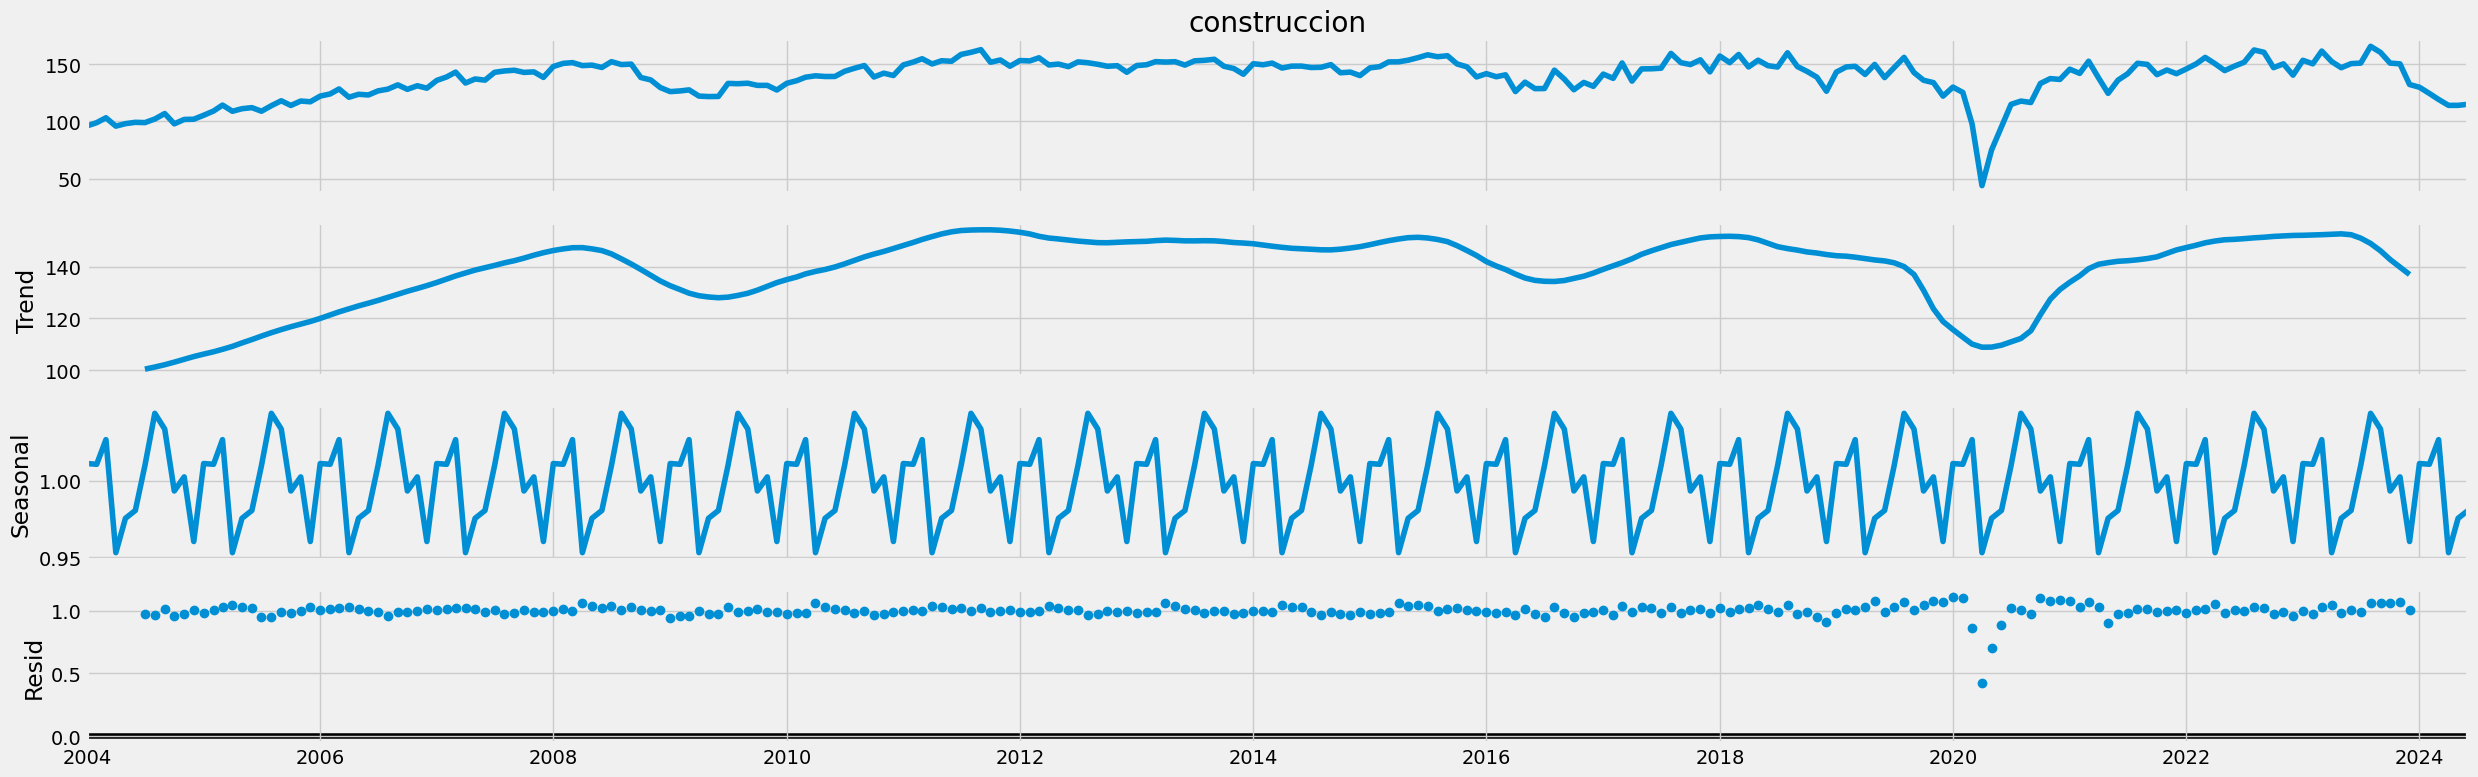

In [28]:
decomposition = sm.tsa.seasonal_decompose(df["construccion"],period =12, model = 'multiplicative')  
figure = decomposition.plot()
plt.show()

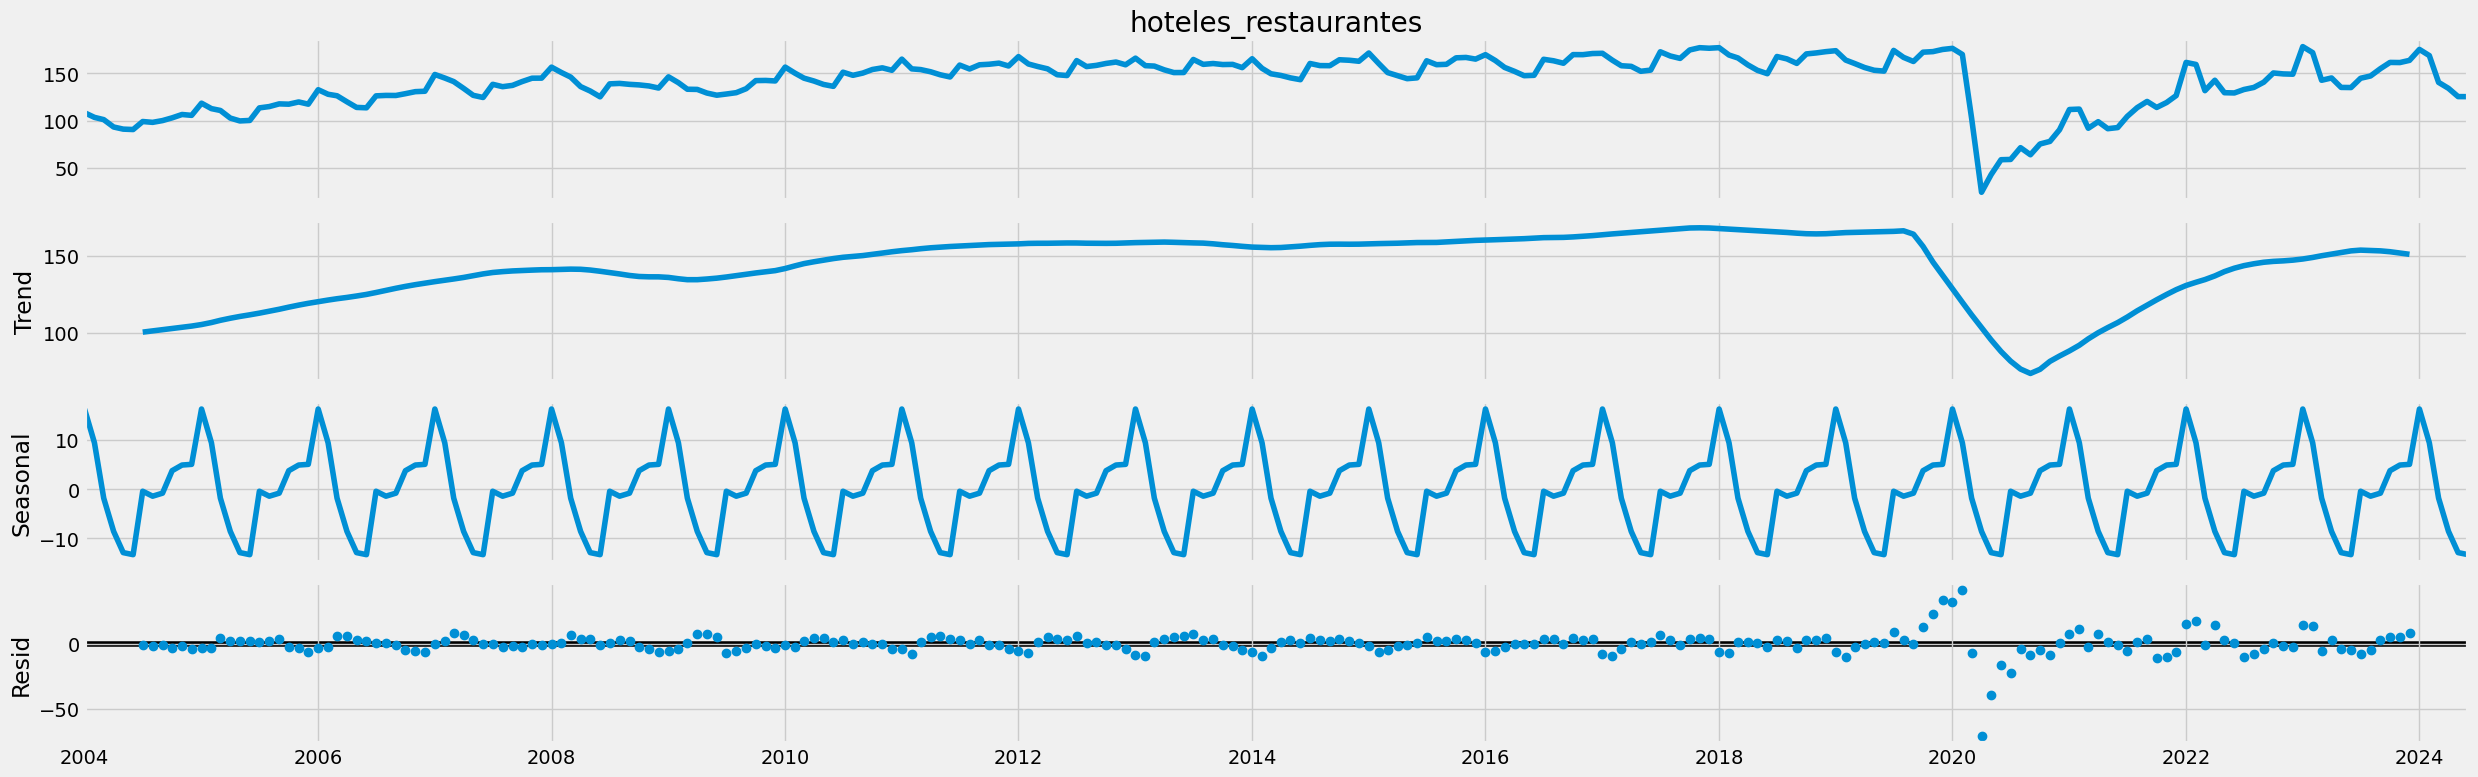

In [29]:
decomposition = sm.tsa.seasonal_decompose(df["hoteles_restaurantes"],period =12)  # 'multiplicative'
figure = decomposition.plot()
plt.show()

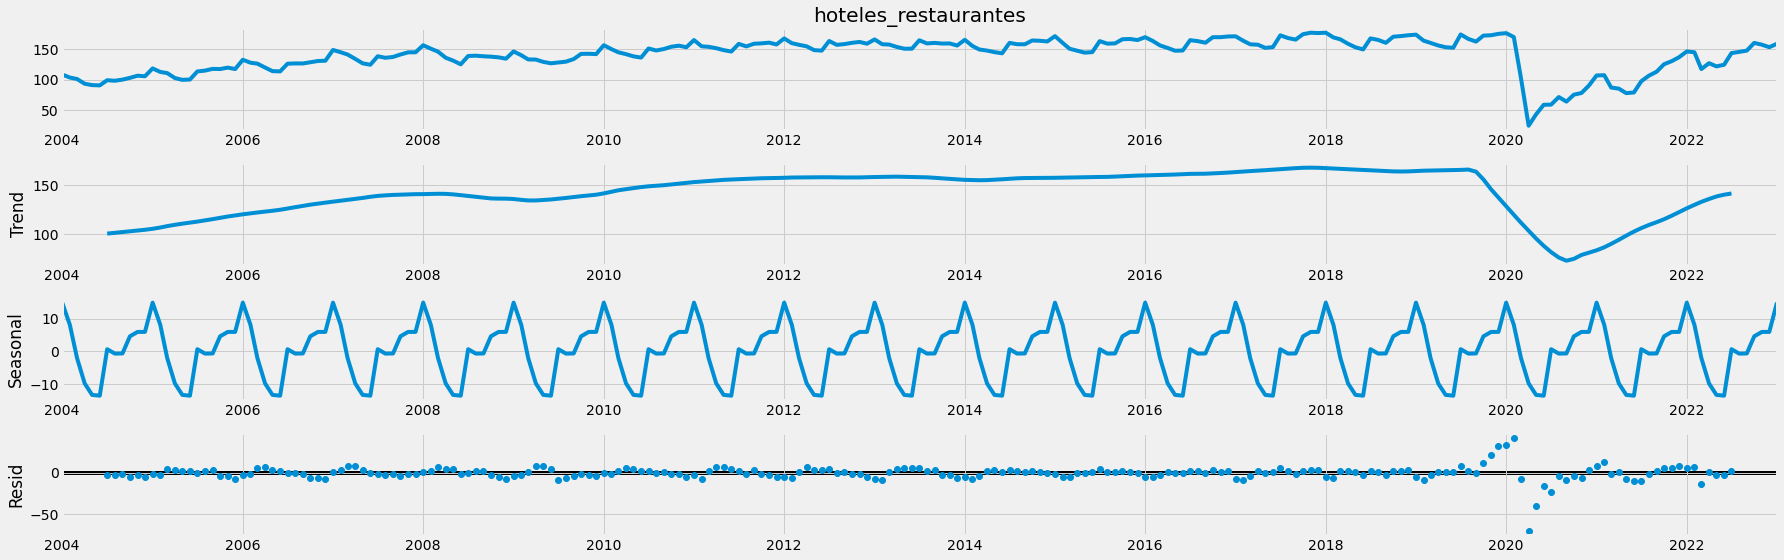

In [19]:
decomposition = sm.tsa.seasonal_decompose(df["hoteles_restaurantes"],period =12)  # 'multiplicative'
figure = decomposition.plot()
plt.show()

<a id="section-four"></a>
# Autocorrelación

### Ruido Blanco

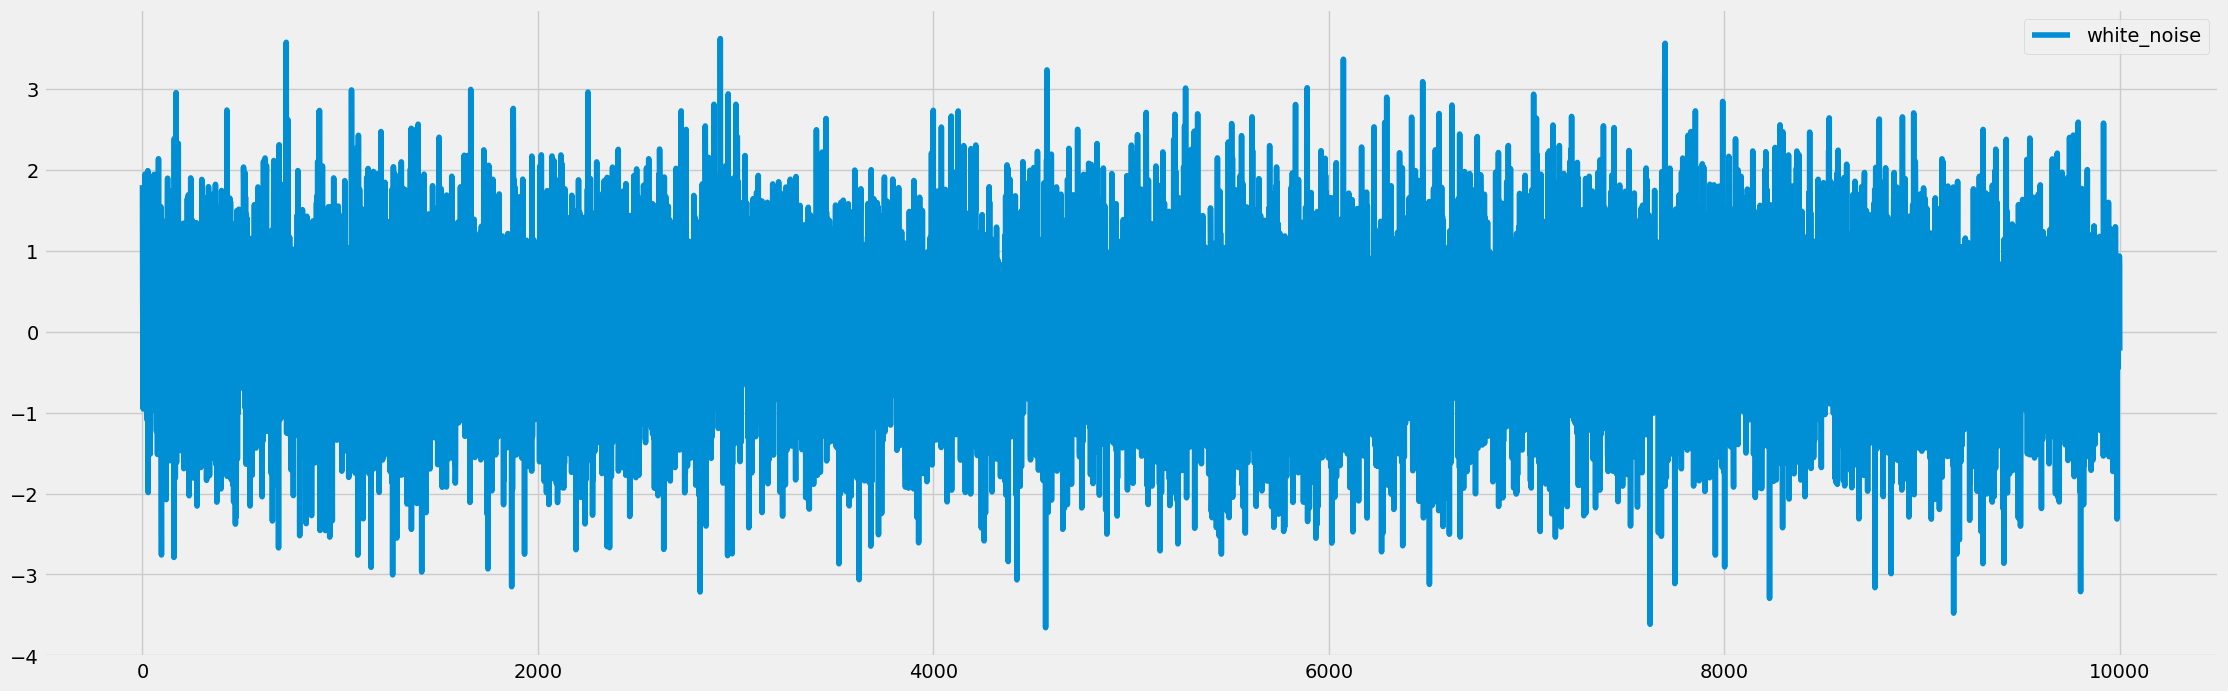

In [30]:
xseries = pd.DataFrame(data = np.random.normal(0, 1, 10000), columns = ['white_noise'] )
xseries.plot()
print()

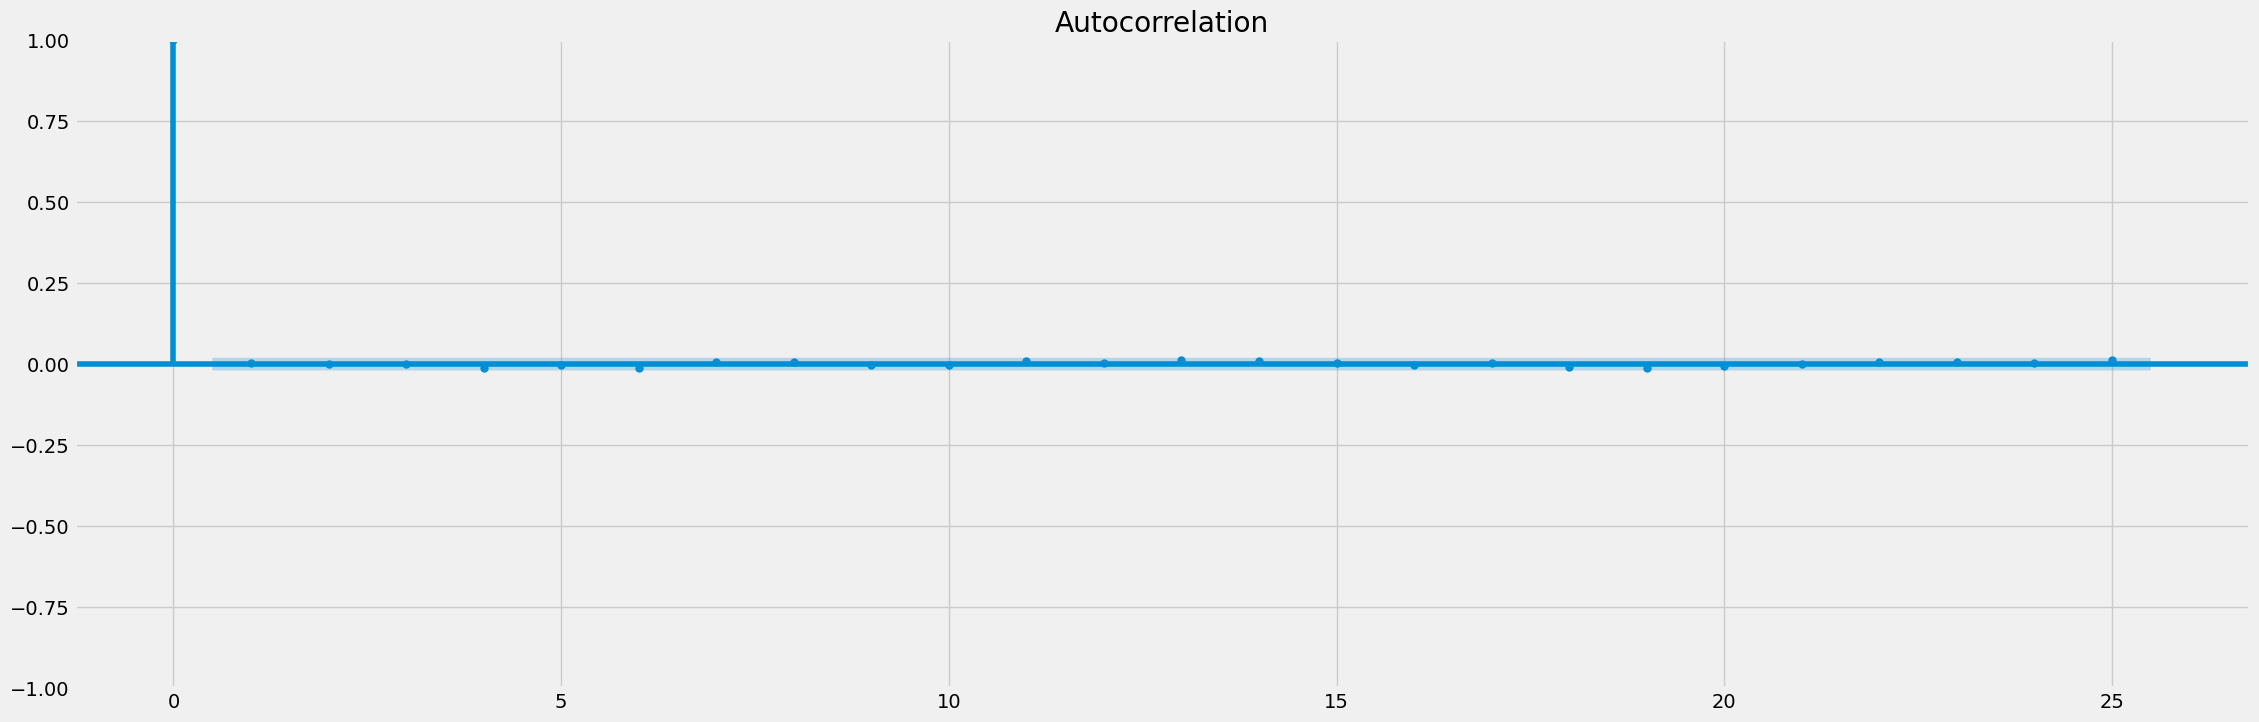

In [31]:
plot_acf(xseries['white_noise'], lags = 25)
print()

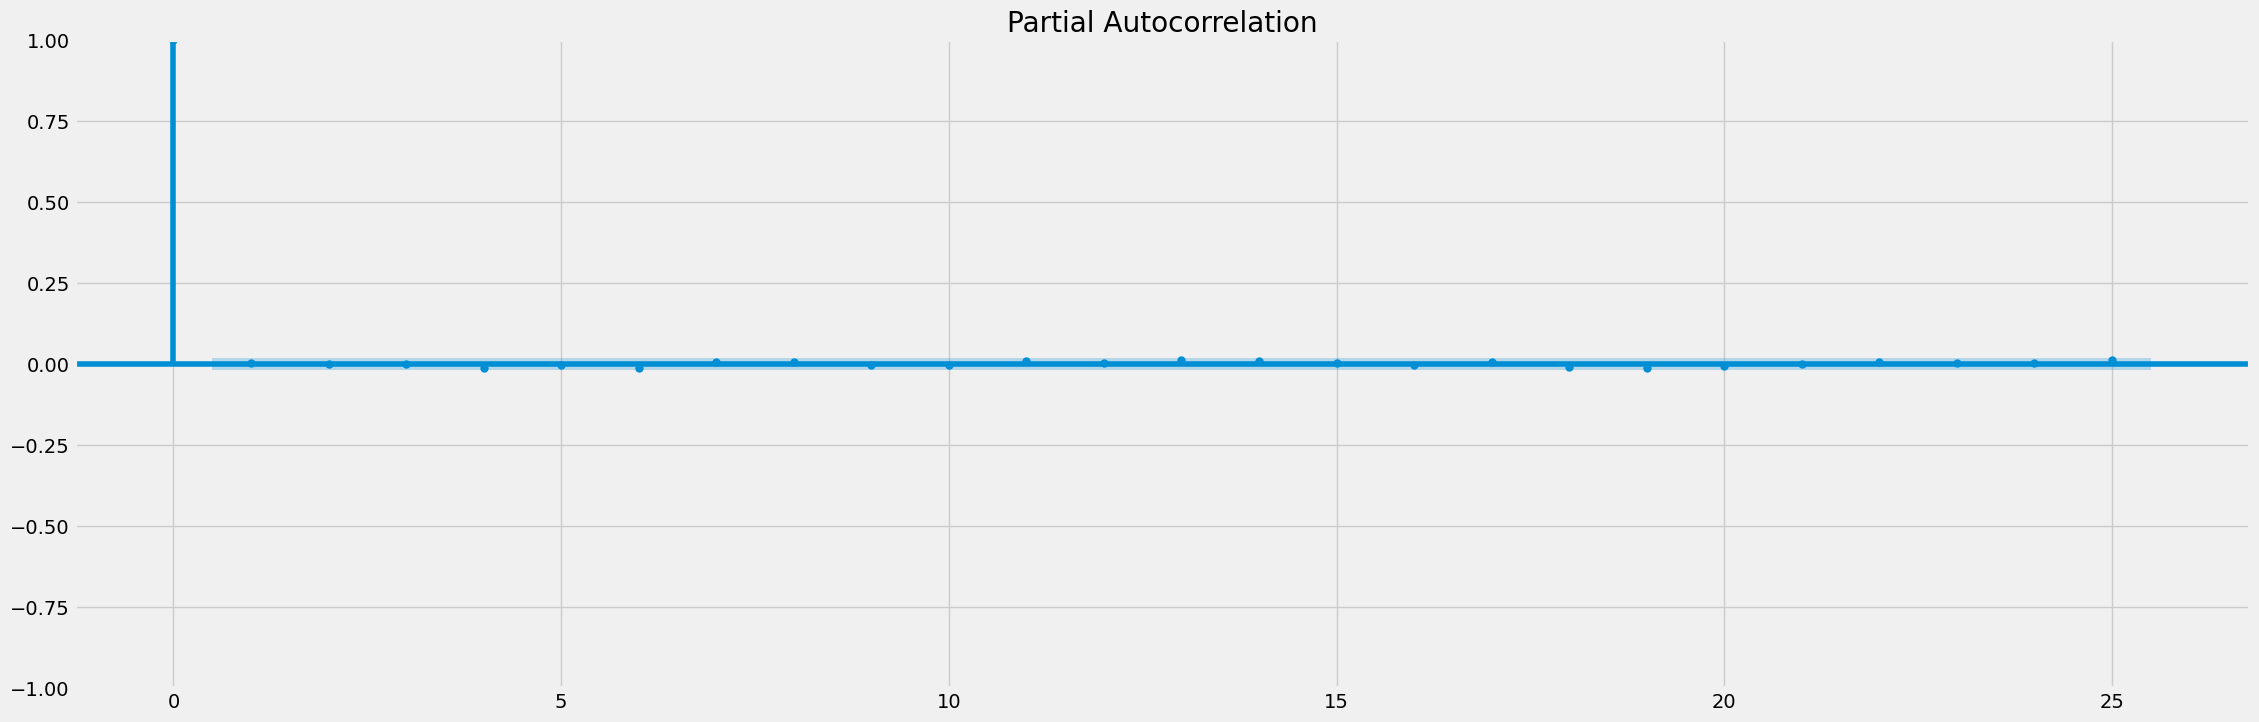

In [32]:
plot_pacf(xseries['white_noise'], lags = 25)
print()

### SUBE

In [33]:
df = sdt_get('678arlyc')#,collapse='week',start_date='2020-05') 
plt.plot(df)

Exception: HTTP Error: 400 - Bad Request

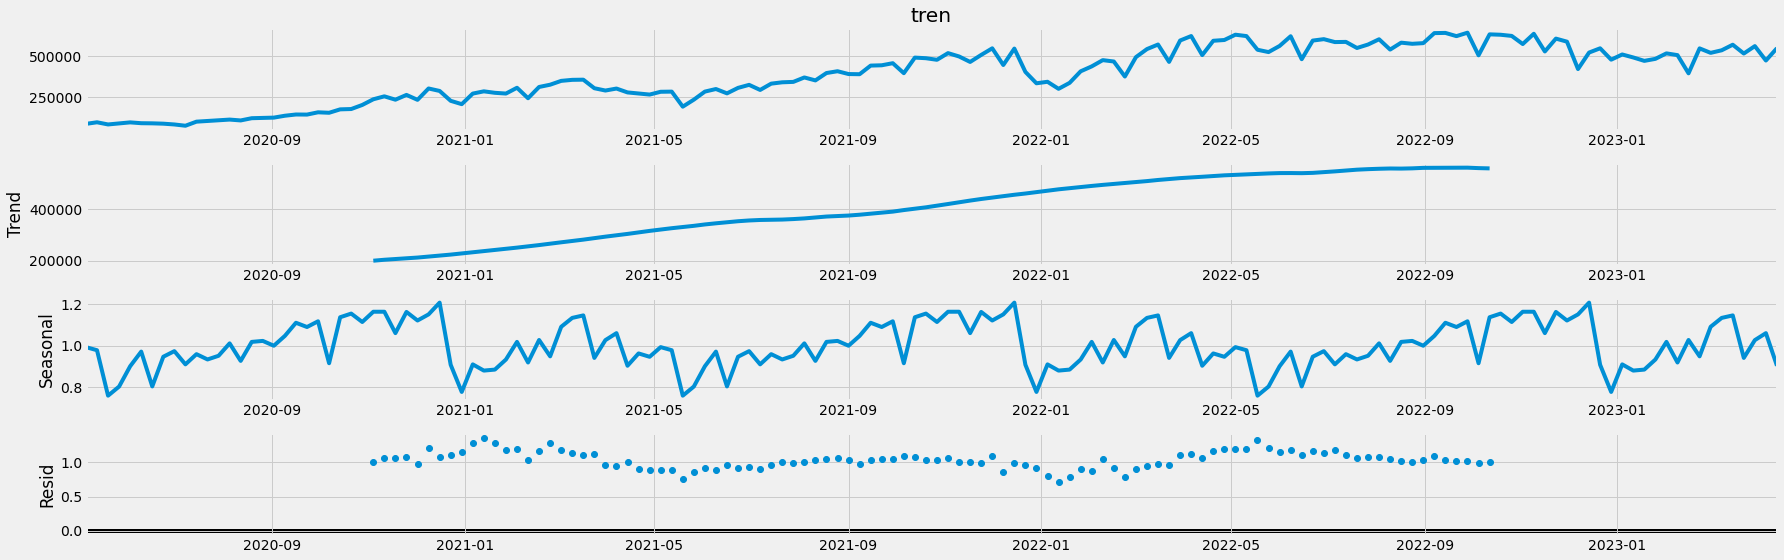

In [25]:
decomposition = sm.tsa.seasonal_decompose(df["tren"],period =52, model = 'multiplicative' ) 
figure = decomposition.plot()
plt.show()

<AxesSubplot:ylabel='Frequency'>

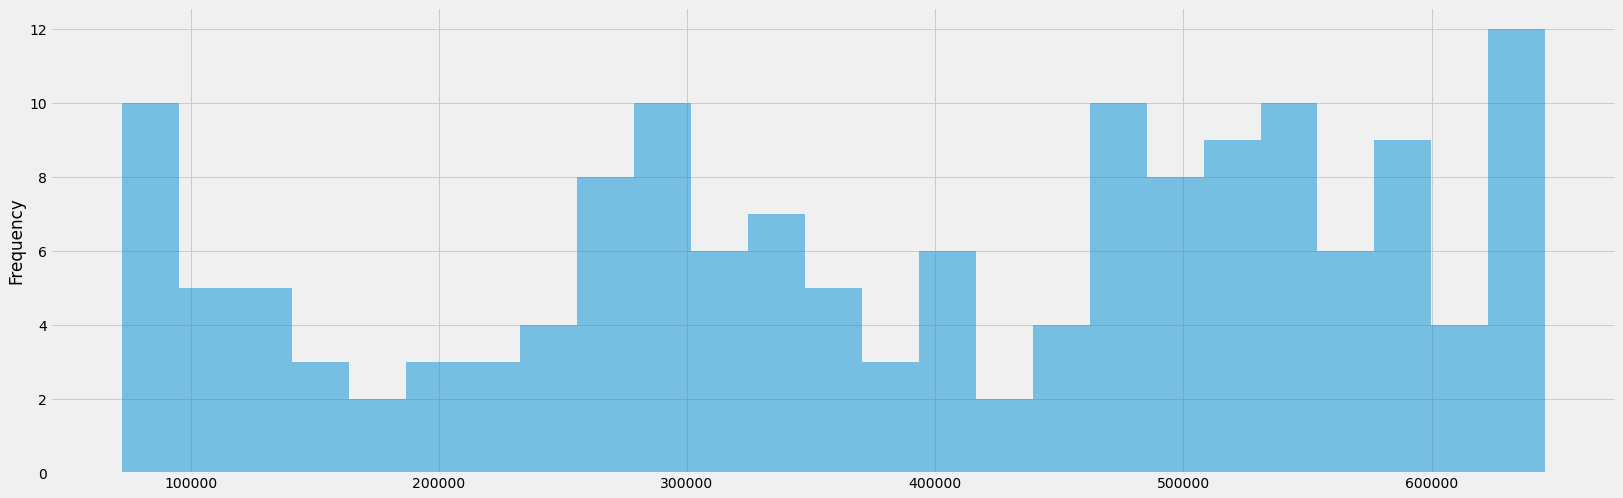

In [26]:
df.tren.plot.hist(bins=25, alpha=0.5)

Obtenemos los primeros momentos de la distribución:

In [29]:
X = df.tren.values
split =  int(len(X) / 2)
X1, X2 = X[0:split], X[split:]
mean1, mean2 = np.round(X1.mean()/1000,0), np.round(X2.mean()/1000,0)
var1, var2 = np.round(X1.std()/1000,0), np.round(X2.std()/1000,0)
print('mean:')
print('chunk1: %.2f vs chunk2: %.2f' % (mean1, mean2))
print('variance:')
print('chunk1: %.2f vs chunk2: %.2f' % (var1, var2))


mean:
chunk1: 248.00 vs chunk2: 530.00
variance:
chunk1: 112.00 vs chunk2: 80.00


In [38]:
def sdt_compare(serie):
    split =  int(len(X) / 2)
    X1, X2 = X[0:split], X[split:]
    mean1, mean2 = np.round(X1.mean(),0), np.round(X2.mean(),0)
    std1, std2 = np.round(X1.std(),0), np.round(X2.std(),0)
    print(f'media A:{mean1} - media B:{mean2} - ratio A/B = {np.round(100*mean1/mean2,2)}%')
    print(f'desvest A : {std1} - desvest B: {std2}  - ratio A/B = {np.round(100*std1/std2,2)}%')
    return [mean1,mean2,std1,std2]

In [39]:
_ = sdt_compare(df.tren.values)

media A:247973.0 - media B:530385.0 - ratio A/B = 46.75%
desvest A : 112411.0 - desvest B: 80339.0  - ratio A/B = 139.92%


### Transformaciones

ACF / PACF

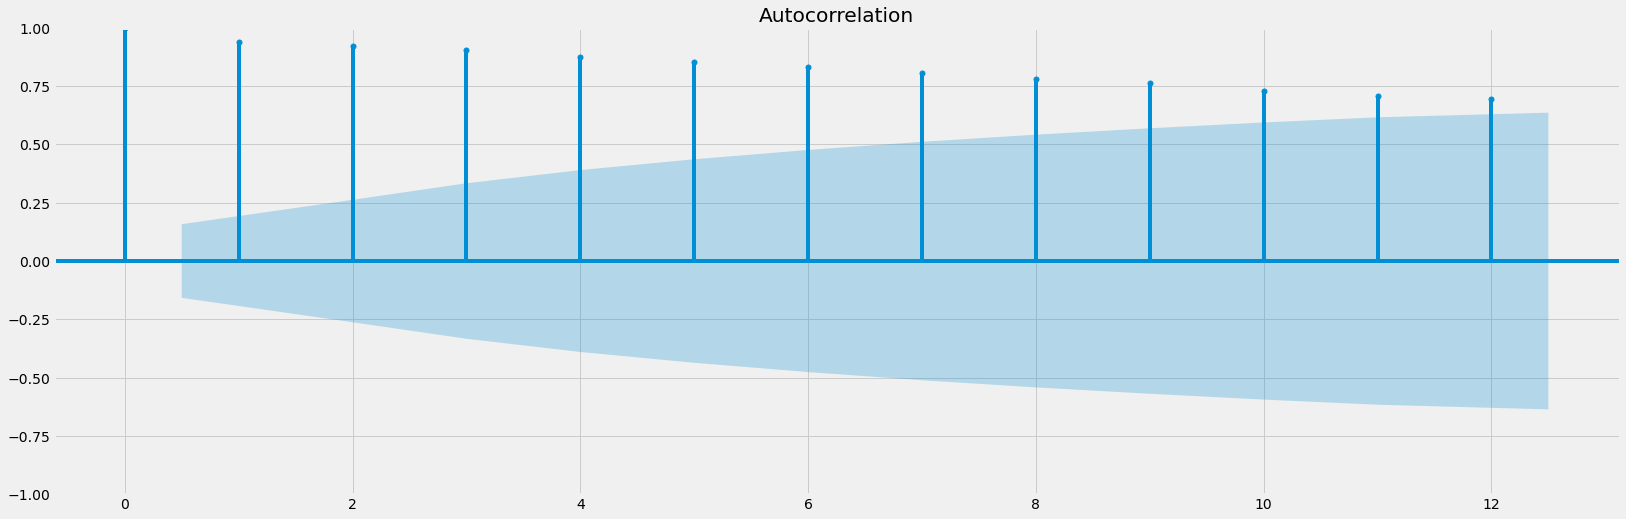

In [43]:
plot_acf(X, lags = 12)
plt.show()

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


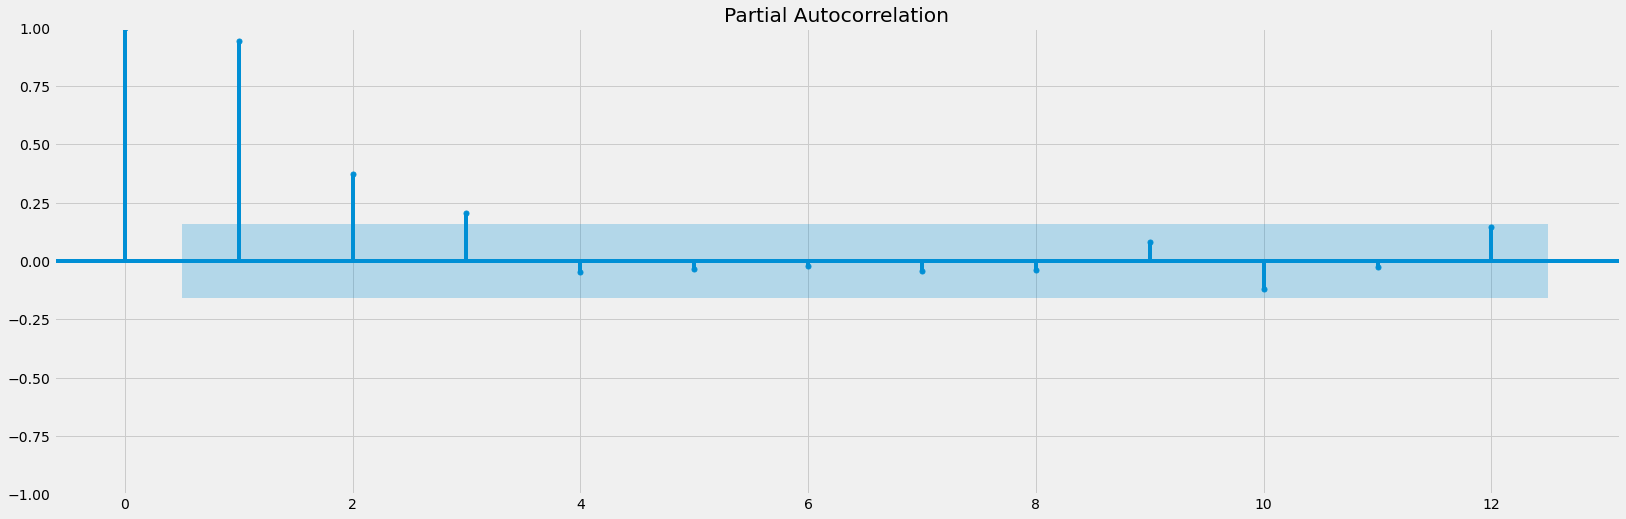

In [44]:
plot_pacf(X, lags = 12)
plt.show()

Qué componente es responsable de la no-estacionariedad?

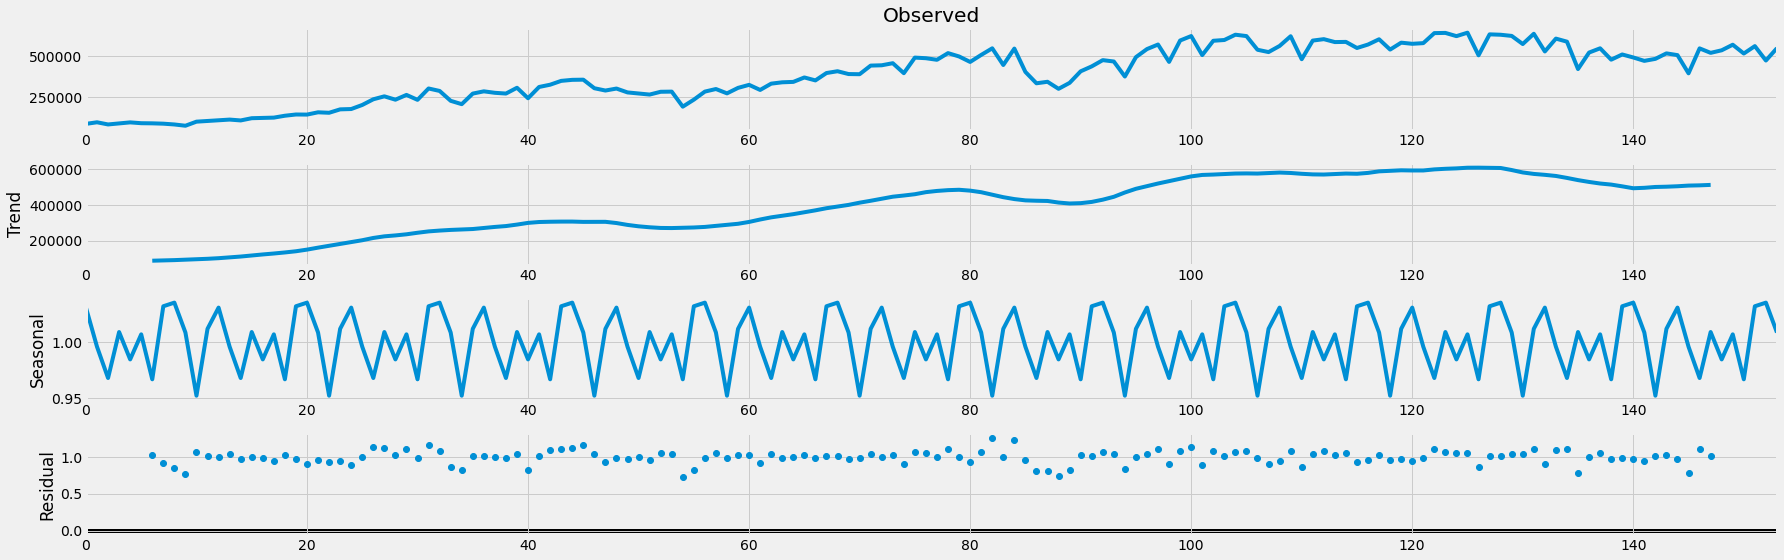

In [45]:
decomposition = seasonal_decompose(X, model='multiplicative', period =12)
figure = decomposition.plot()
plt.show()

## ADF: Test de Estacionariedad

In [40]:
def sdt_adf(serie):
  '''
  Test de Estacionariedad ADF
  '''
  result = adfuller(serie)
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print('\t%s: %.3f' % (key, value))
  return result

In [46]:
result = sdt_adf(X)

ADF Statistic: -1.639875
p-value: 0.462326
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


In [47]:
result = sdt_adf(decomposition.trend[10:-10])

ADF Statistic: -1.618460
p-value: 0.473537
Critical Values:
	1%: -3.486
	5%: -2.886
	10%: -2.580


In [48]:
result = sdt_adf(decomposition.seasonal[10:-10])

ADF Statistic: -360466810608597.375000
p-value: 0.000000
Critical Values:
	1%: -3.486
	5%: -2.886
	10%: -2.580


In [49]:
result = sdt_adf(decomposition.resid[10:-10])

ADF Statistic: -6.615378
p-value: 0.000000
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


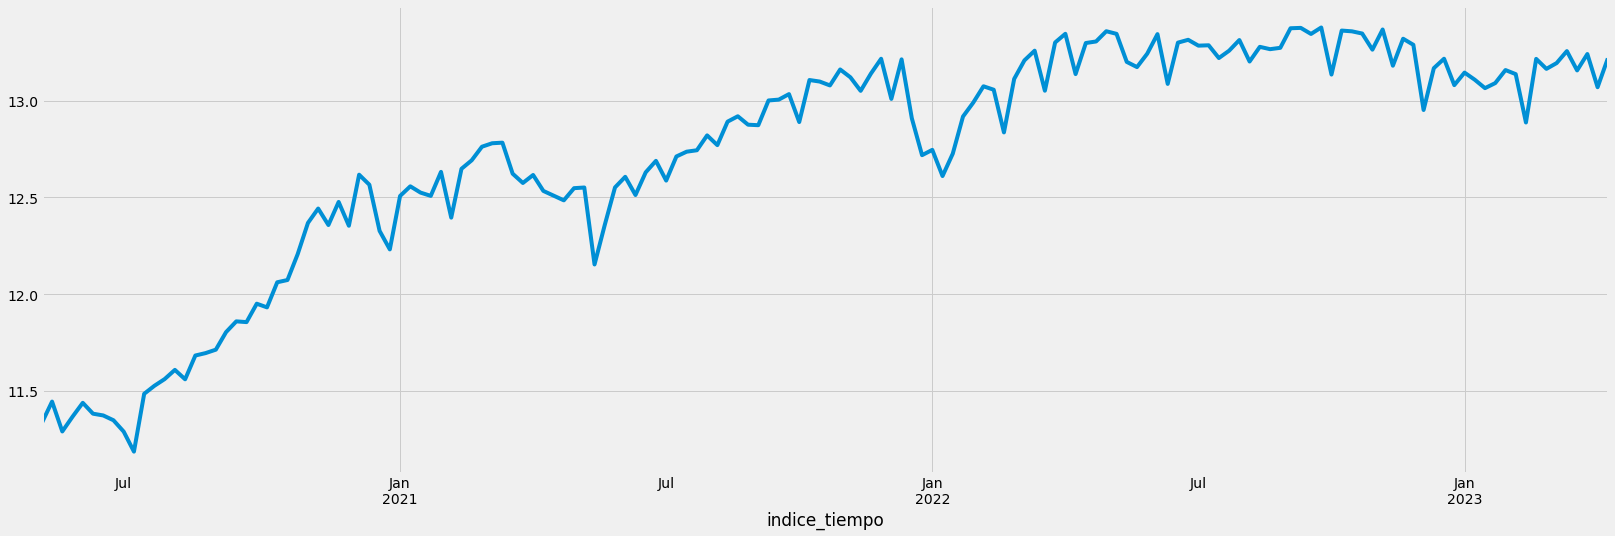

In [50]:
df['tren2'] = np.log(df['tren'])
df.tren2.plot()
plt.show()

La transformación logarítmica nos acerca al rechazo

In [51]:
result = sdt_adf(df.tren2)

ADF Statistic: -2.560683
p-value: 0.101398
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


Si a la transformación logarítmica le aplicamos una diferencia:

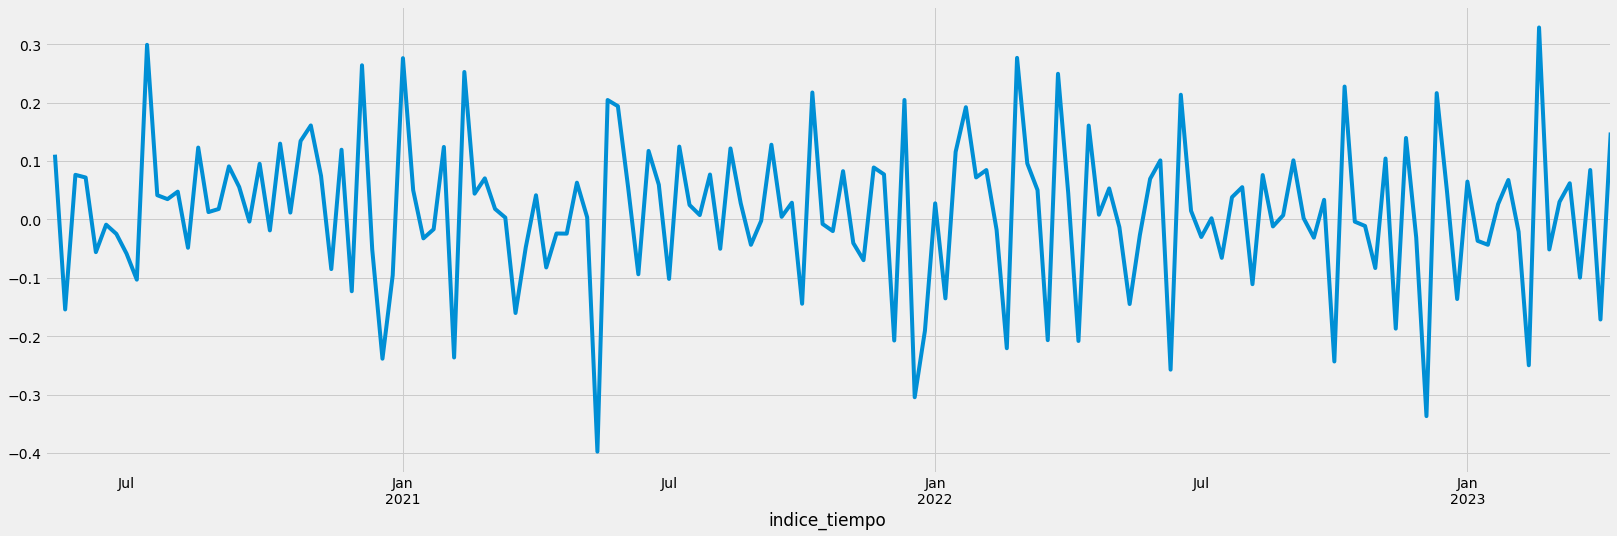

In [52]:
df['diff_tren2'] = df['tren2'].diff()
df.diff_tren2.plot()
plt.show()

Así, obtenemos un rechazo claro:

In [53]:
result = sdt_adf(df.diff_tren2[1:])

ADF Statistic: -12.684296
p-value: 0.000000
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


Integrando las transformaciones en una línea de código:

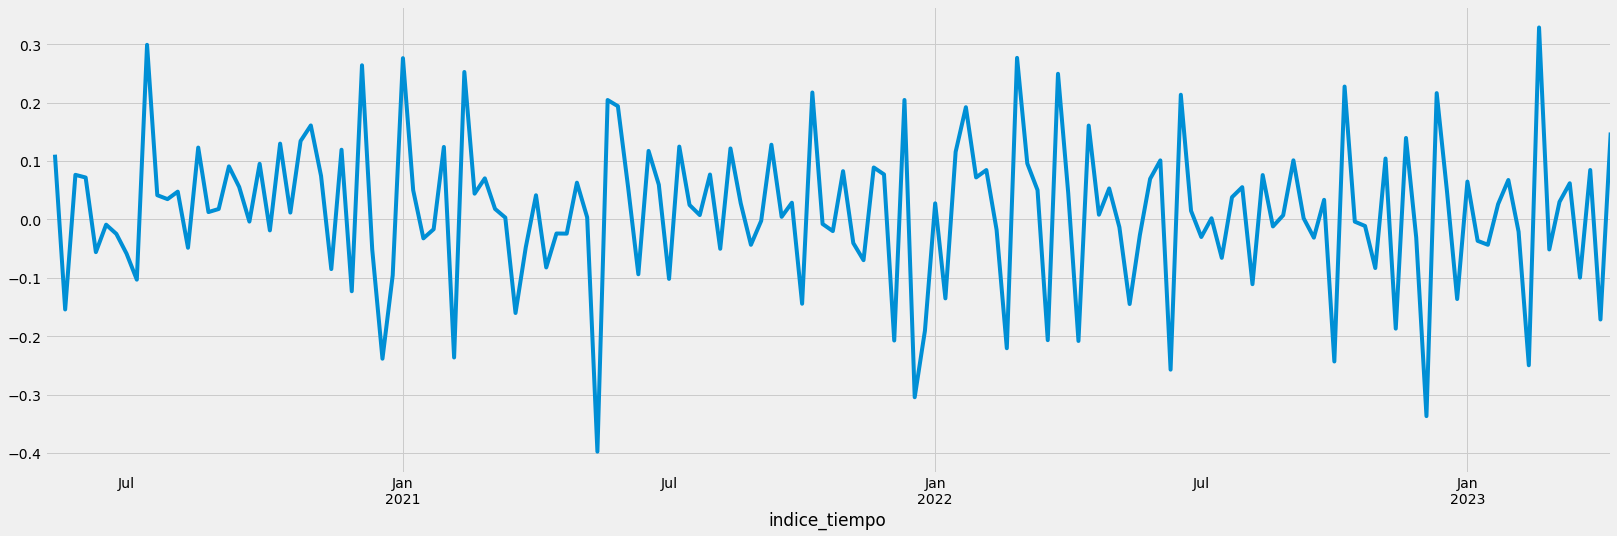

ADF Statistic: -12.684296
p-value: 0.000000
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


In [54]:
df['tren_'] = df['tren'].apply(np.log).diff()
df.tren_.plot()
plt.show()
result = sdt_adf(df.tren_[1:])

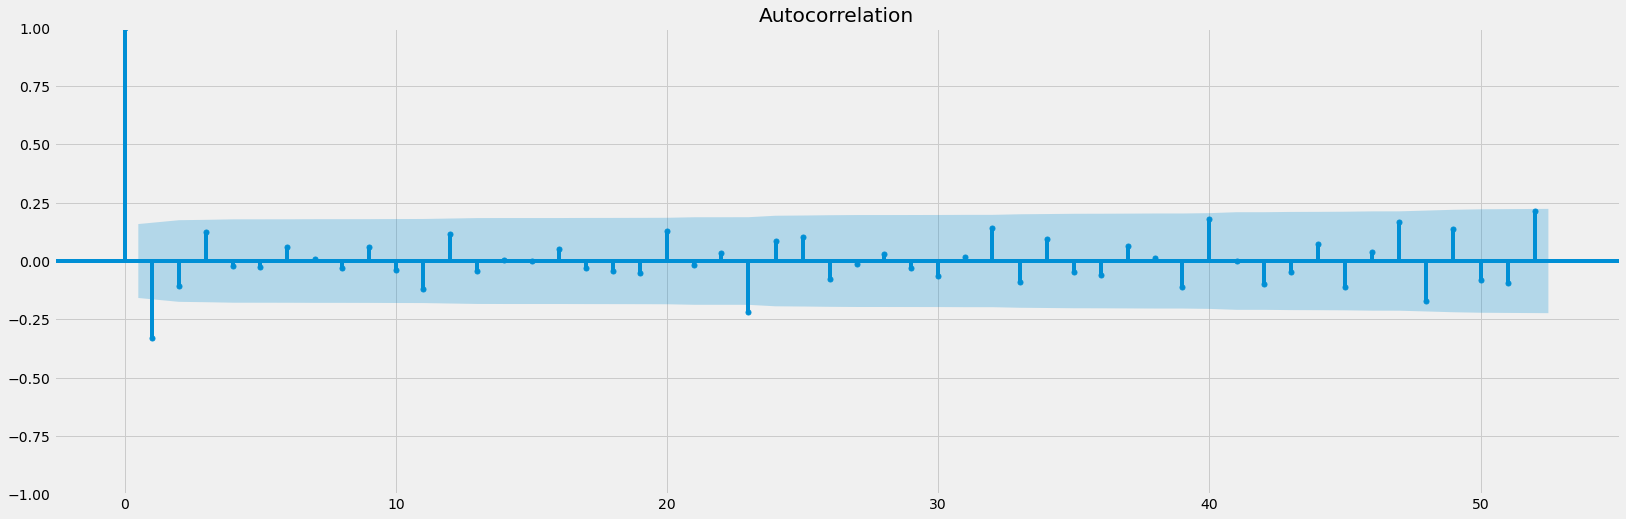

In [55]:
plot_acf(df['tren_'][1:], lags = 52)
plt.show()

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


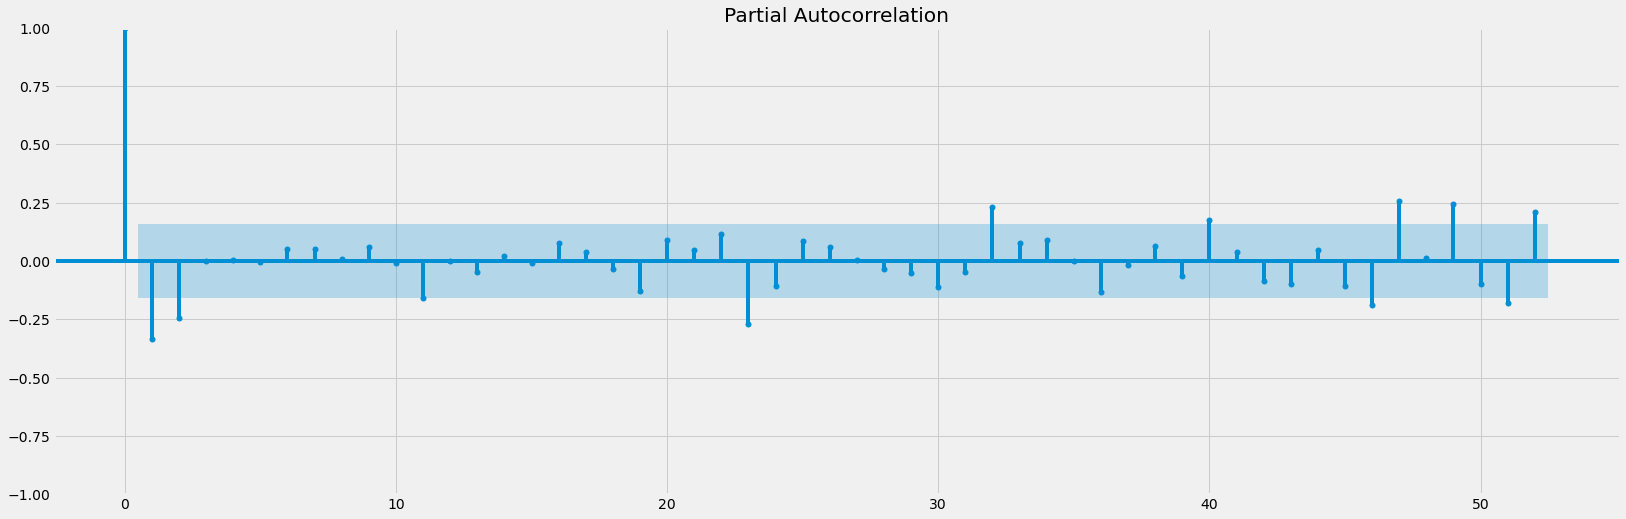

In [56]:
plot_pacf(df['tren_'][1:], lags = 52)
plt.show()

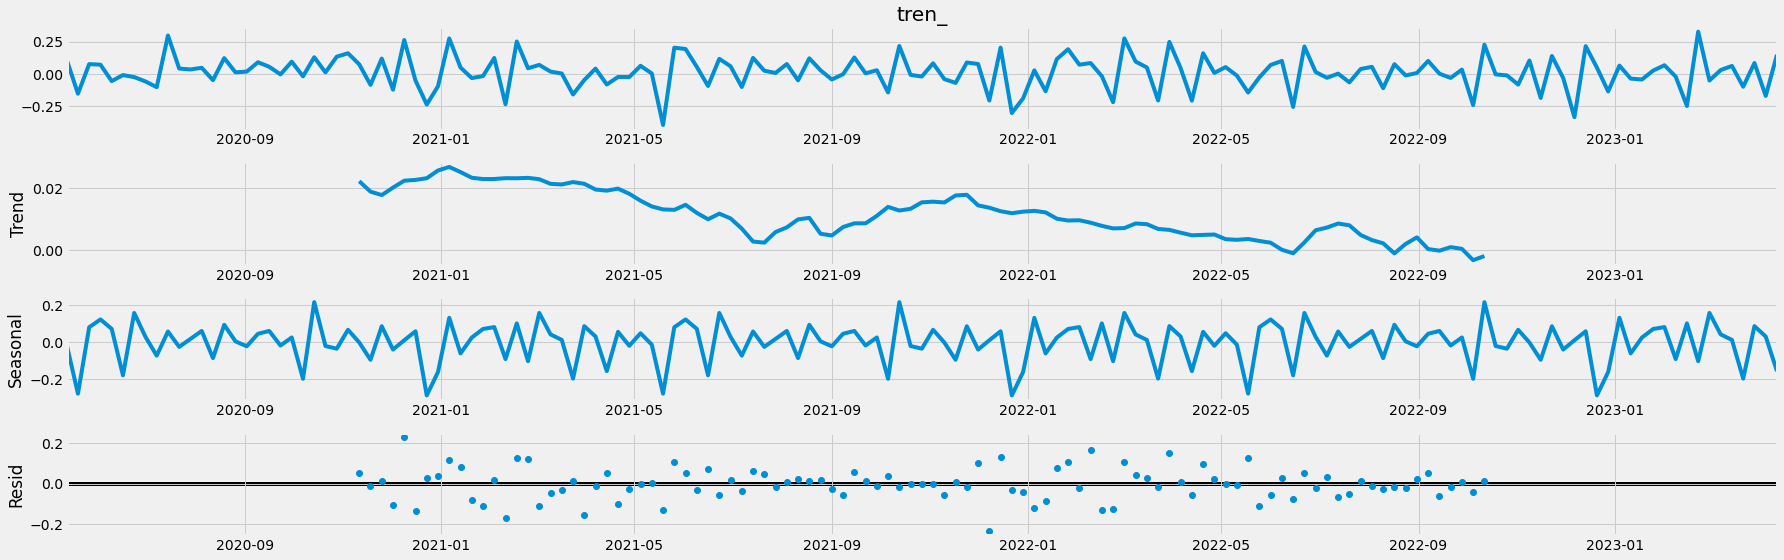

In [57]:
decomposition = sm.tsa.seasonal_decompose(df["tren_"][1:],period =52)
figure = decomposition.plot()
plt.show()

In [70]:
def tsplot(y, lags=None, title='', figsize=(14, 7)):
    '''Examine the patterns of ACF and PACF, along with the time series plot and histogram.
    
    Original source: https://tomaugspurger.github.io/modern-7-timeseries.html
    '''
    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    ts_ax   = plt.subplot2grid(layout, (0, 0))
    hist_ax = plt.subplot2grid(layout, (0, 1))
    acf_ax  = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))
    
    y.plot(ax=ts_ax)
    ts_ax.set_title(title)
    y.plot(ax=hist_ax, kind='hist', bins=25)
    hist_ax.set_title('Histogram')
    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
    [ax.set_xlim(0) for ax in [acf_ax, pacf_ax]]
    sns.despine()
    plt.tight_layout()
    return ts_ax, acf_ax, pacf_ax

(<AxesSubplot:xlabel='indice_tiempo'>,
 <AxesSubplot:title={'center':'Autocorrelation'}>,
 <AxesSubplot:title={'center':'Partial Autocorrelation'}>)

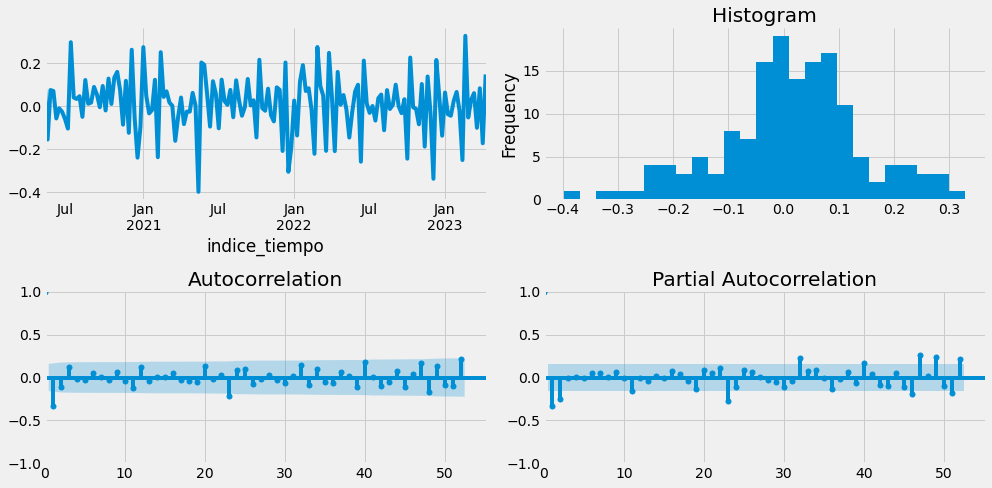

In [71]:
tsplot(df["tren_"][1:],lags=52)

<!-- TODO:
* lag plots
* moar explanations? -->

<!-- <a id="section-five"></a>
# Causality

MOAR: Granger causality test is used to determine if one time series will be useful to forecast another. It is based on the idea that if X causes Y, then the forecast of Y based on previous values of Y AND the previous values of X should outperform the forecast of Y based on previous values of Y alone.
So, Granger causality test should not be used to test if a lag of Y causes Y. Instead, it is generally used on exogenous (not Y lag) variables only. It is implemented in the statsmodel package.
It accepts a 2D array with 2 columns as the main argument. The values are in the first column and the predictor (X) is in the second column. The Null hypothesis is that the series in the second column, does not Granger cause the series in the first. If the P-Values are less than a significance level (0.05) then we reject the null hypothesis and conclude that the said lag of X is indeed useful. The second argument maxlag says till how many lags of Y should be included in the test.a -->